# The Whyte et al. plastic-attractor model, step by step

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bttglc/plastic-attractor-notebook/blob/main/plastic_attractor_model_explained.ipynb)

[GitHub repository](https://github.com/bttglc/plastic-attractor-notebook) | [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/)

## A non-technical guide with a cleaned, auditable implementation

This notebook explains the six-feature-unit model studied in Whyte et al.: its blocked color/shape task, Hebbian learning rule, recurrent dynamics, decoding analysis, and perturbation experiment.

The paper is our scientific idea benchmark. The authors' public repository is our executable reference. Our implementation reorganizes that code for clarity and robustness. When the paper and repository differ, the notebook's decision is recorded in Appendix A.

We will build the idea in this order:

1. understand one green-circle trial;
2. meet the network's two groups of units;
3. see how activity moves for one time step;
4. see how Hebbian learning changes the connections;
5. assemble trials into the paper's blocked experiment;
6. read behavior, activity, decoding, eigenvalues, and perturbation results;
7. test a cleaned implementation of the paper-described frozen-weight control;
8. map the original repository into the notebook's clearer structure;
9. finish with an implementation record of every consequential clarification and deliberate deviation identified here.

> **The one-sentence model:** Two examples of the current rule reshape fast and slow Hebbian connections, which continue changing during trials and bias the recurrent network toward the rule-appropriate response.

The slower component also carries a weak bias across blocks.

## Sources and scientific boundary

The explanations below are anchored to:

- [Whyte et al., *A plastic attractor model of flexible rule-based selective attention*](https://doi.org/10.1101/2025.09.07.674747), bioRxiv version posted 11 September 2025;
- [the authors' public repository](https://github.com/cjwhyte/PlasticAttractor_Attention), inspected at commit [`3e125a2`](https://github.com/cjwhyte/PlasticAttractor_Attention/commit/3e125a2f78239ae5d3906d122ec9d62057a89b66);
- this notebook's self-contained implementation, adapted from the paper and public simulation code.

We use the sources in this order:

1. the paper defines the scientific question, model idea, task, and reported conclusions;
2. the public repository shows the executable equations and indexing choices used by the authors;
3. the cleaned implementation makes those ideas inspectable and easier to extend.

Some descriptions and executable details differ across the sources. Appendix A records the consequential differences identified in this audit, what this notebook chose, and why. This notebook therefore aims for **scientific comparability and transparent implementation**, rather than bit-for-bit reproduction of every seeded value.

The parameter defaults follow the authors' public implementation. Weight initialization is deliberately simplified and kept within the stated bounds. Every required class, function, and analysis is defined in this notebook, so Colab does not need any additional project files.

This is a computational model. Each unit represents average activity across a population. Individual neurons are outside the model's resolution, and model time steps have no automatic millisecond conversion.

### Neuromatch-friendly reading strategy

No neuroscience, programming, or linear-algebra background is assumed. Read the plain-language paragraph first, then use the code cell as a concrete check.

Parameter values are provided for reference. You can revisit eigenvalues after the behavioral story is clear.

## Colab-ready setup

This notebook is **self-contained**. All model and analysis code lives in this file. It uses NumPy, Matplotlib, and scikit-learn, which are included in normal Colab runtimes.

To share it: upload this single `.ipynb` with **File -> Upload notebook**, run **Runtime -> Run all**, then use Colab's **Share** button.

Every figure in this notebook is generated by a visible code cell. If you change the model and run the notebook again, the result figures update too.

The architecture figure is explicitly labeled as a qualitative schematic. All other figures plot arrays calculated during the current run.

The default run includes the paper's 20-seed behavioral benchmark and a compact one-seed TMS teaching analysis. A clearly marked option near the end enables the full cleaned TMS grid, which is much slower.

In [1]:
from dataclasses import dataclass, field
from enum import Enum, IntEnum
from statistics import fmean
import time

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupKFold


# A small shared style keeps the result figures consistent and readable.
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)

print(
    "Self-contained setup ready "
    f"(NumPy {np.__version__}, Matplotlib {matplotlib.__version__}, "
    f"scikit-learn {sklearn.__version__})."
)

Self-contained setup ready (NumPy 1.26.4, Matplotlib 3.8.4, scikit-learn 1.7.2).


# Part I: What task is the model solving?

## [Example] The same object can require opposite responses

Imagine the stimulus is a **green circle**. It contains two simultaneously visible facts:

- its color is green;
- its shape is a circle.

The response mappings are fixed:

| Feature | Response |
|---|---|
| green | left |
| blue | right |
| square | left |
| circle | right |

So green and circle disagree. The missing piece is the **current task rule**:

- in a **color block**, attend to green → choose **left**;
- in a **shape block**, attend to circle → choose **right**.

Both stimulus dimensions remain present. Learning gives the relevant feature a stronger route to the response.

### Self-contained implementation: task vocabulary

Each class is introduced separately below. Together they define the six named
features, the two task rules, one color-shape stimulus, and the response map.

### `Feature`: names for the six vector positions

`IntEnum` gives each meaning both a readable name and an integer index. For
example, `Feature.GREEN` is clearer in code and also selects position 0 in a
NumPy activity vector.

In [2]:
# Enum stands for "enumeration": here we are just mapping different features
# to different integers. This allows us to use more evocative names like "GREEN" etc.
class Feature(IntEnum):
    """Meaning of each position in the six-number feature vector."""

    GREEN = 0
    BLUE = 1
    SQUARE = 2
    CIRCLE = 3
    LEFT = 4
    RIGHT = 5

### `Task`: which stimulus dimension matters now

The task has two possible values: color or shape. It determines which part of
the same visible object should control the response.

In [3]:
# same for Task
class Task(str, Enum):
    COLOR = "color"
    SHAPE = "shape"

### Feature groups and response mappings

The following tuples collect related alternatives so later code can loop over
them. The dictionaries state which feature group belongs to each task and
which response is associated with every sensory feature.

In [4]:
# here we create collections for colors, shapes and responses
# so that we can later cycle on them in an intuitive and pythonic way
# eg.: `for response in response_features` and similar
COLOR_FEATURES = (Feature.GREEN, Feature.BLUE)
SHAPE_FEATURES = (Feature.SQUARE, Feature.CIRCLE)
SENSORY_FEATURES = COLOR_FEATURES + SHAPE_FEATURES
RESPONSE_FEATURES = (Feature.LEFT, Feature.RIGHT)

# same as above, but this time creating collections that deal with the logic
FEATURES_BY_TASK = {
    Task.COLOR: COLOR_FEATURES,
    Task.SHAPE: SHAPE_FEATURES,
}
IRRELEVANT_FEATURES_BY_TASK = {
    Task.COLOR: SHAPE_FEATURES,
    Task.SHAPE: COLOR_FEATURES,
}
RESPONSE_BY_FEATURE = {
    Feature.GREEN: Feature.LEFT,
    Feature.BLUE: Feature.RIGHT,
    Feature.SQUARE: Feature.LEFT,
    Feature.CIRCLE: Feature.RIGHT,
}

### `Stimulus`: one color and one shape

A frozen data class stores the two visible features and validates them when it
is created. `relevant_feature(task)` returns the color during a color task and
the shape during a shape task.

In [5]:
# a frozen data class is one whose role is only to store and validate an input
@dataclass(frozen=True)
class Stimulus:
    """One color-shape combination presented on a trial."""

    # specifying the type of the fields
    color: Feature
    shape: Feature

    # tests to increase robustness after initialization
    def __post_init__(self):
        if self.color not in COLOR_FEATURES:
            raise ValueError(f"{self.color!r} is not a color feature")
        if self.shape not in SHAPE_FEATURES:
            raise ValueError(f"{self.shape!r} is not a shape feature")

    # current task maps the relevant feature
    def relevant_feature(self, task: Task) -> Feature:
        """Select the color or shape according to the current task."""

        if task == Task.COLOR:
            return self.color
        if task == Task.SHAPE:
            return self.shape
        raise ValueError(f"Unknown task: {task!r}")

### The four possible stimuli

Crossing two colors with two shapes produces four objects. We store them once
so every experimental block can use the same complete set.

In [6]:
# a collection holding all combinations of stimuli
ALL_STIMULI = (
    Stimulus(Feature.GREEN, Feature.SQUARE),
    Stimulus(Feature.GREEN, Feature.CIRCLE),
    Stimulus(Feature.BLUE, Feature.SQUARE),
    Stimulus(Feature.BLUE, Feature.CIRCLE),
)

print("Task vocabulary ready: 6 features, 2 tasks, 4 stimuli.")

Task vocabulary ready: 6 features, 2 tasks, 4 stimuli.


### [Example] Green circle under both task rules

Use the same stimulus twice and change only the task. This checks that color
selects green and shape selects circle before any neural simulation begins.

In [7]:
# an assignment to make the next step clearer
# we are gonna use green circle as the main "teaching" example throughout the rest of the notebook
green_circle = Stimulus(Feature.GREEN, Feature.CIRCLE)

# pick either circle or green as the relevant feature
# depending on the value of task
for task in Task:
    relevant = green_circle.relevant_feature(task)
    response = RESPONSE_BY_FEATURE[relevant]
    print(f'{task.value:5s} task: use {relevant.name.lower():6s} -> {response.name.lower()}')

color task: use green  -> left
shape task: use circle -> right


## Congruent and incongruent trials

A trial is **congruent** when color and shape point to the same response. It is **incongruent** when they point to different responses.

| Stimulus | Color says | Shape says | Type |
|---|---:|---:|---|
| green square | left | left | congruent |
| green circle | left | right | incongruent |
| blue square | right | left | incongruent |
| blue circle | right | right | congruent |

Incongruent trials are especially informative because the network cannot succeed by following either dimension indiscriminately. It must express the current rule.

# Part II: What is inside the network?

The model has two interacting populations:

1. **Six feature units** have fixed meanings: green, blue, square, circle, left, right.
2. **Four conjunction units** have no preassigned semantic labels. Through plastic connections, they become useful mixtures of features, rules, and responses.

The matrix **W** connects every feature unit to every conjunction unit. Features influence conjunctions through W.T, and conjunctions feed back to features through W.

> **Qualitative schematic:** the next figure explains the architecture. It is generated by code, but it is a diagram rather than simulation data.

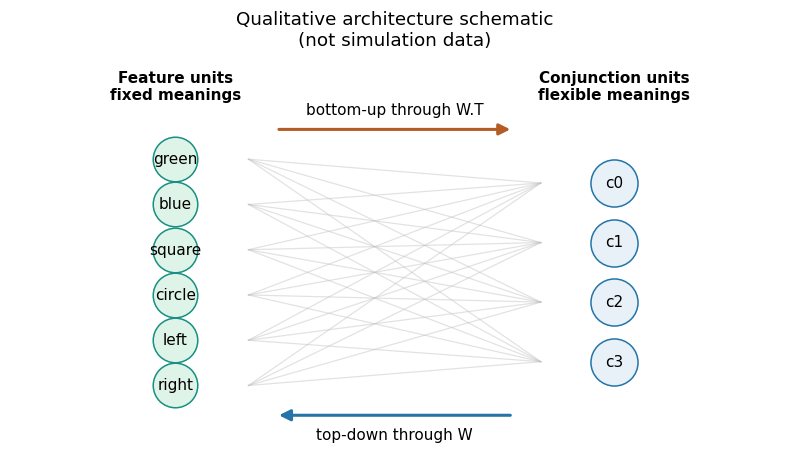

In [8]:
# Draw the two populations using the dimensions defined by the model.
feature_labels = ["green", "blue", "square", "circle", "left", "right"]
feature_y = np.linspace(0.88, 0.12, len(feature_labels))
number_of_conjunction_units_for_figure = 4
conjunction_y = np.linspace(0.80, 0.20, number_of_conjunction_units_for_figure)

fig, ax = plt.subplots(figsize=(9, 4.5))

# Light lines show the all-to-all plastic connectivity.
for fy in feature_y:
    for cy in conjunction_y:
        ax.plot([0.34, 0.66], [fy, cy], color="0.75", linewidth=0.8, alpha=0.45)

ax.scatter(np.full_like(feature_y, 0.26), feature_y, s=850, color="#dff4e8", edgecolor="#178f82")
ax.scatter(
    np.full_like(conjunction_y, 0.74),
    conjunction_y,
    s=950,
    color="#e8f1f8",
    edgecolor="#2474a8",
)

for y, label in zip(feature_y, feature_labels):
    ax.text(0.26, y, label, ha="center", va="center")
for index, y in enumerate(conjunction_y):
    ax.text(0.74, y, f"c{index}", ha="center", va="center")

ax.add_patch(
    FancyArrowPatch(
        (0.37, 0.98),
        (0.63, 0.98),
        arrowstyle="-|>",
        mutation_scale=15,
        color="#b35c24",
        linewidth=2,
    )
)
ax.text(0.50, 1.02, "bottom-up through W.T", ha="center", va="bottom")

ax.add_patch(
    FancyArrowPatch(
        (0.63, 0.02),
        (0.37, 0.02),
        arrowstyle="-|>",
        mutation_scale=15,
        color="#2474a8",
        linewidth=2,
    )
)
ax.text(0.50, -0.02, "top-down through W", ha="center", va="top")

ax.text(0.26, 1.08, "Feature units\nfixed meanings", ha="center", weight="bold")
ax.text(0.74, 1.08, "Conjunction units\nflexible meanings", ha="center", weight="bold")
ax.set_title("Qualitative architecture schematic\n(not simulation data)", pad=16)
ax.set(xlim=(0.08, 0.92), ylim=(-0.10, 1.18))
ax.axis("off")
plt.show()

### Neuroscience translation: what do these units stand for?

| Model element | Neuroscience interpretation |
|---|---|
| color and shape units | sensory populations selective for stimulus features |
| left and right units | motor or response-selective populations |
| conjunction units | flexible, frontoparietal-like populations with mixed selectivity |
| activity value from 0 to 1 | normalized population activity, similar to a firing-rate signal |
| W | effective strength of communication between the populations |

**Mixed selectivity** means that a conjunction unit can respond to combinations of features, tasks, and responses. This flexible code lets the same population represent different combinations in different contexts.

Each unit summarizes a population. The link to frontoparietal cortex remains a functional population-level analogy. Detailed anatomy lies outside the model's scope.

## `NetworkArchitecture`: the network's wiring dimensions

`NetworkArchitecture` stores population sizes and competing feature pairs. Changing activity and learned weights live in separate objects.

The paper's feature groups are:

- `(green, blue)`: the color competitors;
- `(square, circle)`: the shape competitors;
- `(left, right)`: the response competitors.

Within each pair, lateral inhibition makes simultaneous strong activation difficult. The four conjunction units also inhibit one another globally. Competition helps one coherent interpretation win.

### Self-contained implementation: the network

The implementation is divided into small cells. Each explanation appears
immediately before the class or helper it introduces. Run the cells from top
to bottom because later definitions use earlier ones.

In [9]:
# the network contains one unit for every feature and four extra units
# that can learn useful combinations of those features
NUMBER_OF_FEATURE_UNITS = 6
NUMBER_OF_CONJUNCTION_UNITS = 4

# each pair contains alternatives that compete with each other:
# green/blue, square/circle and left/right
FEATURE_GROUPS = ((0, 1), (2, 3), (4, 5))
FEATURES_PER_GROUP = 2

# we define a class that stores the network architecture in terms of
# the constants defined above
@dataclass(frozen=True)
class NetworkArchitecture:
    """Population sizes and mutually competing feature pairs."""

    # same type assignments we did before, with an explicit one
    # for number_of_conjunction_units
    feature_groups: tuple[tuple[int, int], ...]
    number_of_conjunction_units: int = NUMBER_OF_CONJUNCTION_UNITS

    # testing
    def __post_init__(self):
        if any(len(group) != FEATURES_PER_GROUP for group in self.feature_groups):
            raise ValueError("Every feature group must contain exactly two units")
        flattened = tuple(index for group in self.feature_groups for index in group)
        if flattened != tuple(range(len(flattened))):
            raise ValueError("feature_groups must contain each index once, in order")
        if self.number_of_conjunction_units <= 0:
            raise ValueError("number_of_conjunction_units must be positive")

    # utility method
    # functions like this one are mostly useful to reduce 'magic numbers' to a minimum
    # https://en.wikipedia.org/wiki/Magic_number_(programming)
    @property
    def number_of_feature_units(self) -> int:
        return sum(len(group) for group in self.feature_groups)

    # this is basically the same as writing
    # ```
    # architecture = NetworkArchitecture(
    #   feature_groups=((0, 1), (2, 3), (4, 5))
    # )
    # ```
    # cls is just "this class"
    @classmethod
    def original(cls):
        return cls(feature_groups=FEATURE_GROUPS)

### [Example] Inspect the published architecture

Create the default architecture and print the population sizes and competing
feature pairs.

In [10]:
# create the same architecture used by the published model
architecture = NetworkArchitecture.original()

print('feature units:', architecture.number_of_feature_units)
print('conjunction units:', architecture.number_of_conjunction_units)
print('competing feature-index pairs:', architecture.feature_groups)

feature units: 6
conjunction units: 4
competing feature-index pairs: ((0, 1), (2, 3), (4, 5))


## `ModelParameters`: the model's dials

`ModelParameters` collects numeric assumptions in one named, inspectable object. This keeps unexplained numbers out of the equations.

For a first pass, remember three relationships: **self-excitation is positive**, **competition is negative**, and **fast learning is much faster than slow learning**.

| Parameter family | Plain meaning | Public-code value |
|---|---|---:|
| baseline activity | neutral reference level | 0.175 |
| feature self / lateral | persistence and competition inside feature pairs | 0.73 / -0.28 |
| conjunction self / lateral | persistence and global competition | 1.00 / -0.45 |
| conjunction -> feature gain | strength of top-down feedback | 0.08 |
| feature -> conjunction gain | strength of bottom-up input | 0.04 |
| conjunction noise SD | small random variation | 0.005 |
| fast / slow learning rate | speed of Hebbian change | 0.02 / 0.0002 |
| fast / slow upper bound | maximum component weight | 1.0 / 0.2 |

The paper's printed equations assign the two communication gains in the opposite directions. The notebook uses the public repository values because those are tied to the executable results. Appendix A records the discrepancy.

You can override any value with `ModelParameters(name=value)` when testing a new hypothesis.

In [11]:
# all the numbers that control the network live in this one class
# this makes them easy to find, change and report in an experiment
@dataclass(frozen=True)
class ModelParameters:
    """Named parameters for the two coupled neural populations."""

    # the resting level from which increases and decreases are measured
    baseline_activity: float = 0.175

    # self-weights support a unit's own activity
    # negative lateral weights make units compete with other units
    conjunction_lateral_weight: float = -0.45
    conjunction_self_weight: float = 1.00
    feature_lateral_weight: float = -0.28
    feature_self_weight: float = 0.73

    # these gains control communication between the two populations
    conjunction_to_feature_gain: float = 0.08
    feature_to_conjunction_gain: float = 0.04

    # a small amount of random variation is added to conjunction activity
    conjunction_noise_standard_deviation: float = 0.005

    # fast and slow weights learn the same association at different speeds
    fast_learning_rate: float = 0.02
    slow_learning_rate: float = 0.0002
    maximum_fast_weight: float = 1.0
    maximum_slow_weight: float = 0.2

    # reject parameter combinations that cannot represent the stated model
    def __post_init__(self):
        if not 0.0 <= self.baseline_activity <= 1.0:
            raise ValueError("baseline_activity must lie between 0 and 1")
        if self.conjunction_noise_standard_deviation < 0:
            raise ValueError("Noise standard deviation cannot be negative")
        if self.fast_learning_rate < 0 or self.slow_learning_rate < 0:
            raise ValueError("Learning rates cannot be negative")
        if self.maximum_fast_weight <= 0 or self.maximum_slow_weight <= 0:
            raise ValueError("Maximum weights must be positive")

### [Example] Inspect the default parameters

Create `ModelParameters()` and print the values most important for communication
and learning.

In [12]:
# create the default parameters in one readable object
parameters = ModelParameters()

print('top-down, conjunction -> feature:', parameters.conjunction_to_feature_gain)
print('bottom-up, feature -> conjunction:', parameters.feature_to_conjunction_gain)
print('fast learning rate:', parameters.fast_learning_rate)
print('slow learning rate:', parameters.slow_learning_rate)

top-down, conjunction -> feature: 0.08
bottom-up, feature -> conjunction: 0.04
fast learning rate: 0.02
slow learning rate: 0.0002


### `NetworkState`: activity at one moment

`NetworkState` keeps feature activity and conjunction activity together after one update. Its fields cannot be replaced after creation. The model also returns independent array copies, so editing a saved state does not change the live network.

In [13]:
# this small container keeps the activities of both populations together
@dataclass(frozen=True)
class NetworkState:
    """Activity of both populations after one network update."""

    feature_activity: np.ndarray
    conjunction_activity: np.ndarray

### `WeightSnapshot`: learning at one moment

`WeightSnapshot` stores read-only copies of the fast, slow, and combined weights. A snapshot saved before instruction therefore stays unchanged while the live model continues learning.

Keeping weights separate from `NetworkState` prevents activity and connection strength from being confused. Eigenvalue summaries are introduced later, in Part VIII.

In [14]:
# a snapshot lets us inspect the weights at one moment in learning
@dataclass(frozen=True)
class WeightSnapshot:
    """Read-only plastic weights at one moment."""

    fast: np.ndarray
    slow: np.ndarray
    combined: np.ndarray

    def __post_init__(self):
        # copy each array so later learning cannot change this old snapshot
        for name in ("fast", "slow", "combined"):
            values = np.array(getattr(self, name), dtype=float, copy=True)
            values.setflags(write=False)
            object.__setattr__(self, name, values)

## Four terms that must stay separate

| Term | What it is | Code representation | Does it persist between epochs? |
|---|---|---|---|
| input | what the experiment presents now | a six-number NumPy vector | no |
| activity | what each unit is doing now | `NetworkState` | reset to 0 before each epoch |
| trajectory | activity across many time steps | `NetworkTrajectory` | recorded result only |
| weights | learned connection strengths | W, plus fast and slow parts | **yes** |

An **attractor** describes the stable activity pattern toward which the recurrent dynamics settle.

A useful analogy: the **weights shape the landscape**, the **trajectory is the ball's path**, and the **attractor is the valley where the ball tends to settle**. The whole recurrent system produces this valley.

### Neuroscience translation: a population state and a fixed-point attractor

At one instant, the model has ten activity numbers: six feature values plus four conjunction values. Together they form one point in a **neural state space**. As activity changes, that point traces a path called the trajectory.

A **fixed-point attractor** is a population pattern that becomes self-maintaining. Recurrent feedback pulls nearby activity toward it, so the pattern changes less and less.

Strictly, this fixed-point description applies when the input and weights are held fixed and noise is ignored. During the complete experiment, noise and ongoing plasticity can make activity fluctuate around an attractor-like state.

This is one common model of how the brain can maintain a task or decision after the input disappears.

Here, self-excitation supplies persistence, inhibition supplies competition, and learned W makes particular feature-response combinations support one another.

Activity is represented with population rates. The valley is a conceptual picture of the dynamics.

### `_bounded_activity`: keep rates between 0 and 1

The model uses a simple piecewise-linear activation rule. Values below 0
become 0, values above 1 become 1, and values inside the interval are kept.

In [15]:
def _bounded_activity(values: np.ndarray) -> np.ndarray:
    """The paper's piecewise-linear activation function."""

    # neural activity is kept between complete silence and maximum activity
    return np.clip(values, 0.0, 1.0)

# Part III: What happens in one network time step?

## `PlasticAttractor`: the active network

`PlasticAttractor` owns the current activities and weights. Its central method is `step(...)`. One call performs this cycle:

1. subtract the neutral baseline from the current activity;
2. add recurrent influence within each population;
3. add bottom-up and top-down influence through W;
4. add the experiment's external input;
5. add small noise to conjunction units;
6. clip all new activities to the interval from 0 to 1;
7. optionally force conjunctions to 1 for the perturbation;
8. update the plastic weights if learning is enabled;
9. return a copied `NetworkState`.

“Synchronous” means both populations' new values are computed from the previous time step. Each calculation finishes before either new value becomes the current state.

### Implementation of `PlasticAttractor`

This is the largest class because it owns the live activity, fixed recurrent
connections, plastic weights, and the update equation. A useful reading order
is `__init__`, `step`, and `_update_plastic_weights`. The remaining properties
and private helpers support those three operations.

In [16]:
# this is the live network: it holds current activity and changing weights
class PlasticAttractor:
    """Six feature units recurrently coupled to four conjunction units."""

    def __init__(
        self,
        seed: int = 0,
        parameters: ModelParameters | None = None,
        learn: bool = True,
        *,
        architecture: NetworkArchitecture | None = None,
        random_generator: np.random.RandomState | None = None,
    ):
        # if the caller gives no alternatives, use the published parameters
        self.parameters = parameters or ModelParameters()
        self.architecture = architecture or NetworkArchitecture.original()
        self.learn = learn
        # a fixed seed makes the same random initialization reproducible
        self._random = (
            random_generator
            if random_generator is not None
            else np.random.RandomState(seed)
        )

        # recurrent connections stay fixed; plastic connections can learn
        self._feature_recurrent_weights = self._build_feature_connections()
        self._conjunction_recurrent_weights = self._build_conjunction_connections()
        self._initialize_plastic_weights()

        # public experiment epochs begin with zero activity
        self._feature_activity = np.zeros(self.number_of_feature_units)
        self._conjunction_activity = np.zeros(
            self.number_of_conjunction_units
        )

    # these next two functions are just so-called 'getter' methods
    # we interrogate these to retrieve the values instead of accessing them directly
    # you can read more about the 'why' of this at the following link
    # https://en.wikipedia.org/wiki/Encapsulation_(computer_programming)
    @property
    def number_of_feature_units(self) -> int:
        return self.architecture.number_of_feature_units

    @property
    def number_of_conjunction_units(self) -> int:
        return self.architecture.number_of_conjunction_units

    # return copies so code outside the class cannot change the live network
    @property
    def state(self) -> NetworkState:
        return NetworkState(
            feature_activity=self._feature_activity.copy(),
            conjunction_activity=self._conjunction_activity.copy(),
        )

    # the following properties provide the same protection for the weights
    @property
    def weights(self) -> np.ndarray:
        return self._weights.copy()

    @property
    def fast_weights(self) -> np.ndarray:
        return self._fast_weights.copy()

    @property
    def slow_weights(self) -> np.ndarray:
        return self._slow_weights.copy()

    # collect the three matrices in one read-only snapshot
    def weight_snapshot(self) -> WeightSnapshot:
        return WeightSnapshot(
            fast=self._fast_weights,
            slow=self._slow_weights,
            combined=self._weights,
        )

    def reset_activity(self):
        """Reset activity without erasing the learned weights."""

        # this happens at the start of each epoch
        # the learned weight matrices are deliberately left untouched
        self._feature_activity = np.zeros(self.number_of_feature_units)
        self._conjunction_activity = np.zeros(self.number_of_conjunction_units)

    def step(
        self,
        external_input: np.ndarray,
        *,
        clamp_conjunctions: bool = False,
        learn: bool | None = None,
    ) -> NetworkState:
        """Advance the coupled neural and Hebbian equations by one step."""

        # convert the input to a NumPy vector and check that it has six values
        input_vector = np.asarray(external_input, dtype=float)
        expected_shape = (self.number_of_feature_units,)
        if input_vector.shape != expected_shape:
            raise ValueError(
                f"external_input must have shape {expected_shape}; "
                f"received {input_vector.shape}"
            )

        # activity above baseline is positive; activity below it is negative
        p = self.parameters
        centered_features = self._feature_activity - p.baseline_activity
        centered_conjunctions = self._conjunction_activity - p.baseline_activity

        # feature units combine their recurrent input, feedback through W
        # and the stimulus or instruction supplied from outside the network
        next_features = _bounded_activity(
            p.baseline_activity
            + self._feature_recurrent_weights @ centered_features
            + p.conjunction_to_feature_gain
            * (self._weights @ centered_conjunctions)
            + input_vector
        )
        # conjunction units combine recurrent input, feedforward input through
        # W transposed and a small amount of random neural variation
        next_conjunctions = _bounded_activity(
            p.baseline_activity
            + self._conjunction_recurrent_weights @ centered_conjunctions
            + p.feature_to_conjunction_gain
            * (self._weights.T @ centered_features)
            + p.conjunction_noise_standard_deviation
            * self._random.standard_normal(self.number_of_conjunction_units)
        )

        # Noise is drawn before the clamp so paired conditions consume the
        # same random numbers even when their clamp durations differ.
        # The paper's TMS-like pulse then forces every conjunction unit to maximum.
        if clamp_conjunctions:
            next_conjunctions.fill(1.0)

        self._feature_activity = next_features
        self._conjunction_activity = next_conjunctions

        # an individual epoch can temporarily override the model's learn setting
        learning_is_on = self.learn if learn is None else learn
        if learning_is_on:
            self._update_plastic_weights()

        return self.state

    def feedback_eigenvalues(self) -> np.ndarray:
        # W is rectangular; W W.T is square and has real eigenvalues
        return np.linalg.eigvalsh(self._weights @ self._weights.T)

    def number_of_amplifying_eigenvalues(self) -> int:
        return int(np.sum(self.feedback_eigenvalues() > 1.0))

    def _build_feature_connections(self) -> np.ndarray:
        # begin with no competition, then mark the three competing pairs
        within_dimension = np.zeros(
            (self.number_of_feature_units, self.number_of_feature_units)
        )
        for group in self.architecture.feature_groups:
            within_dimension[np.ix_(group, group)] = 1.0

        # the identity matrix adds self-support to the diagonal
        # the pair matrix adds negative competition inside each pair
        p = self.parameters
        return (
            p.feature_self_weight * np.eye(self.number_of_feature_units)
            + p.feature_lateral_weight * within_dimension
        )

    def _build_conjunction_connections(self) -> np.ndarray:
        # all four conjunction units support themselves and compete globally
        p = self.parameters
        return (
            p.conjunction_self_weight * np.eye(self.number_of_conjunction_units)
            + p.conjunction_lateral_weight
            * np.ones(
                (self.number_of_conjunction_units, self.number_of_conjunction_units)
            )
        )

    def _initialize_plastic_weights(self):
        # initialize each timescale inside its own allowed range
        shape = (self.number_of_feature_units, self.number_of_conjunction_units)
        p = self.parameters
        self._fast_weights = self._random.uniform(
            0.0, p.maximum_fast_weight, size=shape
        )
        self._slow_weights = self._random.uniform(
            0.0, p.maximum_slow_weight, size=shape
        )
        # W begins, and always remains, the sum of fast and slow weights
        self._weights = self._fast_weights + self._slow_weights

    def _update_plastic_weights(self):
        p = self.parameters
        # the outer product creates one Hebbian change for every pair
        # of feature and conjunction units
        change = np.outer(
            self._feature_activity - p.baseline_activity,
            self._conjunction_activity - p.baseline_activity,
        )
        # apply the same association with a fast rate and a slow rate
        # clipping prevents either matrix from growing without limit
        self._fast_weights = np.clip(
            self._fast_weights + p.fast_learning_rate * change,
            0.0,
            p.maximum_fast_weight,
        )
        self._slow_weights = np.clip(
            self._slow_weights + p.slow_learning_rate * change,
            0.0,
            p.maximum_slow_weight,
        )
        # neural activity uses the sum of the two learned matrices
        self._weights = self._fast_weights + self._slow_weights


print("Core network ready: neural activity and Hebbian plasticity are defined.")

Core network ready: neural activity and Hebbian plasticity are defined.


### [Example] Inspect the newly created model

The next cell creates one seeded model and checks the shapes of its activity
vectors and weight matrices. Reading shapes is often the quickest way to
understand how populations connect.

In [17]:
# seed 0 gives us a reproducible example network
model = PlasticAttractor(seed=0)

# inspect current activity and weights without changing either one
state = model.state
snapshot = model.weight_snapshot()

print('current feature activity shape:', state.feature_activity.shape)
print('current conjunction activity shape:', state.conjunction_activity.shape)
print('combined W shape:', snapshot.combined.shape)
print('fast W shape:', snapshot.fast.shape)
print('slow W shape:', snapshot.slow.shape)

current feature activity shape: (6,)
current conjunction activity shape: (4,)
combined W shape: (6, 4)
fast W shape: (6, 4)
slow W shape: (6, 4)


## [Example] One update for a green circle

The input `[1, 0, 0, 1, 0, 0]` strongly drives green and circle and gives no direct motor answer. Learning is turned off in this small demonstration so we can inspect activity alone. The model begins with the same zero activity used at the start of each experimental epoch.

The helper `_bounded_activity(...)`, defined just above the network class, clips activity to the interval from 0 to 1. This example constructs its input directly. `_stimulus_vector(...)` is introduced later when we build complete trial epochs.

In [18]:
# turn learning off so this cell shows neural activity alone
model = PlasticAttractor(seed=0, learn=False)

# start with no external input, then activate green and circle
green_circle_input = np.zeros(NUMBER_OF_FEATURE_UNITS)
green_circle_input[green_circle.color] = 1.0
green_circle_input[green_circle.shape] = 1.0
# save activity before and after one update of the network equations
before = model.state
after = model.step(green_circle_input)

print('external input:', green_circle_input)
print('features before:', np.round(before.feature_activity, 3))
print('features after one step:', np.round(after.feature_activity, 3))
print('conjunctions after one step:', np.round(after.conjunction_activity, 3))

external input: [1. 0. 0. 1. 0. 0.]
features before: [0. 0. 0. 0. 0. 0.]
features after one step: [1.    0.106 0.103 1.    0.106 0.098]
conjunctions after one step: [0.281 0.273 0.281 0.294]


## How W creates a feedback loop

W has shape **6 x 4**:

- six rows: green, blue, square, circle, left, right;
- four columns: the four conjunction units.

**Bottom-up:** each of the four conjunction units needs a weighted combination of six feature activities. Transposing W swaps its rows and columns, giving the required calculation:

```text
W.T @ feature_activity
(4, 6) @ (6,) -> (4,)
```

The transpose changes the matrix orientation. It does not calculate a matrix inverse.

**Top-down:** each of the six feature units needs a weighted combination of four conjunction activities, so the original orientation already fits:

```text
W @ conjunction_activity
(6, 4) @ (4,) -> (6,)
```

This closes the loop:

```text
features -> conjunction pattern -> features -> conjunction pattern -> ...
```

If learning has linked green, a particular conjunction pattern, and left, then green can reactivate that pattern, which feeds back toward left. The repeated loop can make a response-selective state stable.

# Part IV: What does Hebbian learning change?

## The covariance rule in plain language

For every feature unit *i* and conjunction unit *j*, the code computes:

**change(i,j) = (feature(i) − baseline) × (conjunction(j) − baseline)**

Then it multiplies that change by a learning rate and adds it to the corresponding weight.

- both units above baseline → positive product → connection strengthens;
- one above and one below baseline → negative product → connection weakens;
- either unit near baseline → little change.

This is more precise than the slogan “cells that fire together wire together”: the model measures co-activity **relative to baseline**. The NumPy operation `np.outer(...)` computes all 6 × 4 pairings at once.

### [Example] One Hebbian weight change

Use a deliberately simple activity pattern to see which entries of the
feature-by-conjunction matrix receive a positive change.

In [19]:
# make a tiny example where green, left and one conjunction unit are active
baseline = parameters.baseline_activity
example_features = np.array([1.0, baseline, baseline, baseline, 1.0, baseline])
example_conjunctions = np.array([0.9, baseline, baseline, baseline])
# subtract baseline, then pair every feature with every conjunction unit
hebbian_change = np.outer(
    example_features - baseline,
    example_conjunctions - baseline,
)

print('Rows are features; columns are conjunction units:')
print(np.round(hebbian_change, 3))

Rows are features; columns are conjunction units:
[[0.598 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.598 0.    0.    0.   ]
 [0.    0.    0.    0.   ]]


Only two entries are positive in this toy example: the active conjunction unit is being associated with both green and left. On later trials, the shared conjunction unit can help carry activity from green toward left.

The real simulation performs this update after every network step, using the activity that actually emerged. The weights are clipped so they cannot grow without bound.

## Fast and slow weights

The model maintains two copies of each feature-conjunction connection:

| Component | Learning rate | Upper bound | Intuition |
|---|---:|---:|---|
| fast W | 0.02 | 1.0 | changes quickly with the current task experience |
| slow W | 0.0002 | 0.2 | accumulates much more gradually |

The effective matrix is simply:

**combined W = fast W + slow W**

The method `_update_plastic_weights()` applies the same covariance signal to both parts at different rates. `weight_snapshot()` preserves all three weight views. The eigenvalue diagnostic is introduced in Part VIII.

The slow component has an important role in the paper. The authors added it to carry a weak bias across blocks and stabilize which combinations the conjunction units represent. Their supplementary ablation reports that removing the slow component disrupted the behavioral congruency effect and made conjunction selectivity less stable across blocks. This notebook explains that rationale but does not execute the slow-weight ablation.

Fast and slow W represent generic **timescales of synaptic plasticity**. The model assigns no particular receptor or molecular process.

> The task remains fixed within a block while W continues changing. Activity resets at every epoch, while learned weights carry information forward.

# Part V: How does the code turn this into an experiment?

## `TimeWindow` and `EpochProtocol`: the clock

One epoch lasts 400 model steps. The readable code uses **half-open intervals**: `TimeWindow(51, 101)` contains steps 51 through 100, so its duration is exactly 50.

| Phase | Code window | Duration | Meaning |
|---|---:|---:|---|
| instruction presentation | 0:251 | 251 | one mapping is co-activated |
| stimulus | 51:101 | 50 | color and shape are externally driven |
| response period | 101:351 | 250 | stimulus is gone; network settles |
| whole epoch | 0:400 | 400 | includes inactive periods |

These are the intervals actually produced by the public code's inclusive conditions. The paper describes rounded durations: 250 instruction steps followed by 150 inactive steps, and 100 inactive trial steps surrounding the 50-step stimulus and 250-step response. The executable arrays divide those inactive trial steps into 51 before the stimulus and 49 after the response.

`EpochProtocol` keeps this convention in one place and prevents mixed boundary comparisons from spreading through the simulation.

### Self-contained implementation: the experiment

The experiment is also divided into explanation-then-code units. Classes get
their own cells. A few small helper functions share a cell when they perform
one closely related translation.

In [20]:
# this helper represents a span of simulation steps
@dataclass(frozen=True)
class TimeWindow:
    """A half-open interval: start is included and stop is excluded."""

    start: int
    stop: int

    # reject impossible windows as soon as they are created
    def __post_init__(self):
        if self.start < 0 or self.stop <= self.start:
            raise ValueError("A time window needs 0 <= start < stop")

    # for TimeWindow(51, 101), step 51 is included and step 101 is excluded
    def contains(self, time_step: int) -> bool:
        return self.start <= time_step < self.stop

    @property
    def duration(self) -> int:
        return self.stop - self.start

### `EpochProtocol`: all timing in one recipe

`EpochProtocol` groups the windows and durations used by instructions and
trials. `default_factory` creates a fresh `TimeWindow` for every protocol.

In [21]:
# one place for the timing rules used throughout the published experiment
@dataclass(frozen=True)
class EpochProtocol:
    """Timing used by the public implementation."""

    # every instruction or trial epoch lasts 400 network updates
    number_of_steps: int = 400

    # default_factory creates a fresh TimeWindow for every protocol object
    instruction_window: TimeWindow = field(
        default_factory=lambda: TimeWindow(0, 251)
    )
    stimulus_window: TimeWindow = field(
        default_factory=lambda: TimeWindow(51, 101)
    )
    response_window: TimeWindow = field(
        default_factory=lambda: TimeWindow(101, 351)
    )
    response_search_start: int = 110
    repeats_per_stimulus: int = 3

    def __post_init__(self):
        if self.number_of_steps <= 0:
            raise ValueError("number_of_steps must be positive")
        for window in (
            self.instruction_window,
            self.stimulus_window,
            self.response_window,
        ):
            if window.stop > self.number_of_steps:
                raise ValueError("Protocol windows must fit inside the epoch")
        if not 0 <= self.response_search_start < self.number_of_steps:
            raise ValueError("response_search_start must lie inside the epoch")
        if self.repeats_per_stimulus <= 0:
            raise ValueError("repeats_per_stimulus must be positive")

### [Example] Inspect the timing boundaries

Before building trials, print the three windows and check their durations.
This makes the temporal protocol visible without reading array slices.

In [22]:
# create the default schedule and inspect its important boundaries
protocol = EpochProtocol()

for name in ('instruction_window', 'stimulus_window', 'response_window'):
    window = getattr(protocol, name)
    print(f'{name:20s}: {window.start:3d}:{window.stop:3d}  duration={window.duration}')
print('whole epoch:', protocol.number_of_steps, 'steps')
print('response measurement begins at absolute step:', protocol.response_search_start)

instruction_window  :   0:251  duration=251
stimulus_window     :  51:101  duration=50
response_window     : 101:351  duration=250
whole epoch: 400 steps
response measurement begins at absolute step: 110


### `ConjunctionClamp`: the paper's optional perturbation

The paper models nonspecific stimulation by forcing all conjunction units to
maximum activity during a short window. `ConjunctionClamp` stores that window.
The later `author_tms_pulse(...)` helper translates the public code's inclusive
dose label into the half-open windows used here.

This is a phenomenological manipulation. It contains no electromagnetic or
coil physics and can be ignored when focusing on the task-switching proposal.

In [23]:
# the paper models a TMS-like disturbance by forcing conjunction activity to 1
@dataclass(frozen=True)
class ConjunctionClamp:
    """Force every conjunction unit to maximum activity in a time window."""

    window: TimeWindow

    # a convenient way to create a clamp from its first and final boundaries
    @classmethod
    def between(cls, start: int, stop: int) -> "ConjunctionClamp":
        return cls(TimeWindow(start, stop))

    # place a pulse directly before the stimulus window ends
    @classmethod
    def ending_with_stimulus(
        cls,
        duration_in_steps: int,
        protocol: EpochProtocol | None = None,
    ):
        if duration_in_steps <= 0:
            raise ValueError("duration_in_steps must be positive")
        timing = protocol or EpochProtocol()
        stop = timing.stimulus_window.stop
        start = stop - duration_in_steps
        if start < 0:
            raise ValueError("Clamp duration begins before the epoch")
        return cls.between(start, stop)

    def is_active(self, time_step: int) -> bool:
        return self.window.contains(time_step)

    @property
    def duration_in_steps(self) -> int:
        return self.window.duration

### Convert the public perturbation label

In the public program, a positive label `d` includes both endpoints. The helper
therefore creates a clamp lasting `d + 1` model steps.

In [24]:
# the public program labels pulse boundaries inclusively
# therefore a label of 11 corresponds to 12 simulated steps
def author_tms_pulse(
    labeled_dose: int,
    protocol: EpochProtocol | None = None,
) -> ConjunctionClamp | None:
    """Translate the public implementation's inclusive dose label."""

    if labeled_dose < 0:
        raise ValueError("labeled_dose cannot be negative")
    if labeled_dose == 0:
        return None
    return ConjunctionClamp.ending_with_stimulus(
        duration_in_steps=labeled_dose + 1,
        protocol=protocol,
    )

### `NetworkTrajectory`: activity across an epoch

A trajectory is the activity movie recorded during one epoch. Rows represent
time steps. Columns represent feature or conjunction units.

In [25]:
# a trajectory stores the full activity history, with time running down rows
@dataclass(frozen=True)
class NetworkTrajectory:
    """Time-by-unit activity recorded during one epoch."""

    feature_activity: np.ndarray
    conjunction_activity: np.ndarray

## `run_epoch`: reset activity, keep learning

An **epoch** is one 400-step simulation segment: either an instruction presentation or a task trial.

`run_epoch(model, inputs, protocol, ...)` does four things:

1. calls `model.reset_activity()`, which sets both activity arrays to 0;
2. calls `model.step(...)` once for every row of the input schedule;
3. optionally activates a conjunction clamp;
4. records every returned state in a `NetworkTrajectory`.

`NetworkTrajectory.feature_activity` has shape `(400, 6)`. Its rows are time points; its columns are named feature units. The conjunction array has shape `(400, 4)`.

`run_epoch` validates the complete input shape, then resets activity while preserving the same `PlasticAttractor` and its learned W. This separation lets instruction affect a later trial.

In [26]:
def run_epoch(
    model: PlasticAttractor,
    inputs: np.ndarray,
    protocol: EpochProtocol,
    *,
    perturbation: ConjunctionClamp | None = None,
    learn: bool | None = None,
) -> NetworkTrajectory:
    """Reset activity, advance every step, and record the trajectory."""

    input_array = np.asarray(inputs, dtype=float)
    expected_shape = (
        protocol.number_of_steps,
        model.number_of_feature_units,
    )
    if input_array.shape != expected_shape:
        raise ValueError(
            f"inputs must have shape {expected_shape}; "
            f"received {input_array.shape}"
        )

    # every epoch starts with fresh activity while learned weights persist
    model.reset_activity()

    # reserve arrays that will hold one row for every simulated step
    feature_history = np.empty(
        (protocol.number_of_steps, model.number_of_feature_units)
    )
    conjunction_history = np.empty(
        (protocol.number_of_steps, model.number_of_conjunction_units)
    )

    # repeatedly update the network and save the activity that follows
    for time_step in range(protocol.number_of_steps):
        # clamp becomes True only during the requested TMS-like window
        clamp = perturbation is not None and perturbation.is_active(time_step)
        state = model.step(
            input_array[time_step],
            clamp_conjunctions=clamp,
            learn=learn,
        )
        feature_history[time_step] = state.feature_activity
        conjunction_history[time_step] = state.conjunction_activity

    return NetworkTrajectory(feature_history, conjunction_history)

### `BlockedExperimentConfig`: the experiment recipe

This frozen class stores the seed, number of blocks, timing, model parameters,
optional perturbation, and whether learning continues during trials. An even
number of blocks gives equal numbers of color and shape blocks.

In [27]:
# the configuration collects every choice needed to repeat an experiment
@dataclass(frozen=True)
class BlockedExperimentConfig:
    """Everything needed to reproduce one alternating-block simulation."""

    seed: int = 0
    number_of_blocks: int = 20
    protocol: EpochProtocol = field(default_factory=EpochProtocol)
    model_parameters: ModelParameters = field(
        default_factory=ModelParameters
    )
    perturbation: ConjunctionClamp | None = None
    learn_during_trials: bool = True

    # an even number gives the same number of colour and shape blocks
    def __post_init__(self):
        if self.number_of_blocks <= 0:
            raise ValueError("number_of_blocks must be positive")
        if self.number_of_blocks % 2:
            raise ValueError("number_of_blocks must be even")
        if (
            self.perturbation is not None
            and self.perturbation.window.stop > self.protocol.number_of_steps
        ):
            raise ValueError("perturbation window must fit inside the epoch")

### `TrialResult`: everything recorded about one trial

One result stores the task, stimulus, correct and chosen responses, reaction
time, perturbation, and complete activity trajectory. Its `correct` and
`congruent` properties are computed from those stored facts.

In [28]:
# one TrialResult keeps everything we may want to inspect about one trial
@dataclass(frozen=True)
class TrialResult:
    seed: int
    block_index: int
    trial_index_in_block: int
    task: Task
    stimulus: Stimulus
    correct_response: Feature
    chosen_response: Feature | None
    reaction_time_in_steps: float
    perturbation: ConjunctionClamp | None
    trajectory: NetworkTrajectory

    # these two facts can be calculated from the stored trial information
    @property
    def correct(self) -> bool:
        return (
            self.chosen_response is not None
            and self.chosen_response == self.correct_response
        )

    @property
    def congruent(self) -> bool:
        color_response = _correct_response(Task.COLOR, self.stimulus)
        shape_response = _correct_response(Task.SHAPE, self.stimulus)
        return color_response == shape_response

### `ExperimentResult`: everything returned after all blocks

This record joins the configuration, every trial, the number of amplifying
modes after each block, and the final learned matrix.

In [29]:
# the complete result joins all trials with block and final-weight summaries
@dataclass(frozen=True)
class ExperimentResult:
    config: BlockedExperimentConfig
    trials: tuple[TrialResult, ...]
    amplifying_eigenvalue_count_by_block: tuple[int, ...]
    final_weights: np.ndarray

## Instruction epochs teach the current rule

At the start of a color block, the experiment presents two associations:

- green together with left;
- blue together with right.

At the start of a shape block, it presents:

- square together with left;
- circle together with right.

The irrelevant sensory pair receives a moderate input of 0.5. The relevant feature and response receive 1.0; their alternatives receive −1.0.

These co-activations drive Hebbian changes in W. Instruction occurs through examples of the two mappings. No symbolic `COLOR` input is presented.

In [30]:
# construct one teaching example such as green -> left
def _instruction_vector(
    task: Task,
    relevant_feature: Feature,
    response: Feature,
) -> np.ndarray:
    # begin by suppressing every feature
    vector = np.full(NUMBER_OF_FEATURE_UNITS, -1.0)
    # give the irrelevant dimension a moderate neutral input
    vector[list(IRRELEVANT_FEATURES_BY_TASK[task])] = 0.5
    # strongly activate the relevant feature and its correct response together
    vector[relevant_feature] = 1.0
    vector[response] = 1.0
    return vector


# each task has two mappings to teach, one for each relevant feature
def _instruction_vectors(task: Task) -> tuple[np.ndarray, np.ndarray]:
    first_feature, second_feature = FEATURES_BY_TASK[task]
    return (
        _instruction_vector(task, first_feature, RESPONSE_BY_FEATURE[first_feature]),
        _instruction_vector(task, second_feature, RESPONSE_BY_FEATURE[second_feature]),
    )


# turn one six-value instruction into a complete 400-step input schedule
def _instruction_epoch(
    instruction: np.ndarray,
    protocol: EpochProtocol,
) -> np.ndarray:
    # the instruction is shown only inside its time window
    inputs = np.full((protocol.number_of_steps, NUMBER_OF_FEATURE_UNITS), -1.0)
    window = protocol.instruction_window
    inputs[window.start : window.stop] = instruction
    return inputs

### [Example] Print the instruction vectors

Display the two mapping examples used to teach each block rule.

In [31]:
# Feature can be looped over directly, giving all six positions in order
# we turn their names into readable labels for the printed input values
labels = [feature.name.lower() for feature in Feature]

# show the two learned mappings for colour and then for shape
for task in Task:
    print(f'\n{task.value.upper()} block instructions')
    for vector in _instruction_vectors(task):
        print({label: float(value) for label, value in zip(labels, vector)})


COLOR block instructions
{'green': 1.0, 'blue': -1.0, 'square': 0.5, 'circle': 0.5, 'left': 1.0, 'right': -1.0}
{'green': -1.0, 'blue': 1.0, 'square': 0.5, 'circle': 0.5, 'left': -1.0, 'right': 1.0}

SHAPE block instructions
{'green': 0.5, 'blue': 0.5, 'square': 1.0, 'circle': -1.0, 'left': 1.0, 'right': -1.0}
{'green': 0.5, 'blue': 0.5, 'square': -1.0, 'circle': 1.0, 'left': -1.0, 'right': 1.0}


## Trial epochs present the object and leave the response to the network

For a green circle, `_stimulus_vector(...)` produces:

```text
green blue square circle left right
  1     0     0      1     0    0
```

No motor answer is injected. Both green and circle are present even though one is irrelevant. The learned recurrent dynamics must resolve their competition according to the task context established by the instruction epochs.

The private helpers keep this translation explicit:

- `_instruction_vectors(task)` builds the two mappings;
- `_instruction_epoch(vector, protocol)` places one mapping in time;
- `_stimulus_vector(stimulus)` converts an object to six numbers;
- `_trial_epoch(stimulus, protocol)` places that vector in time;
- `_correct_response(task, stimulus)` computes the answer used for scoring.

In [32]:
# represent an object by activating its colour unit and its shape unit
def _stimulus_vector(stimulus: Stimulus) -> np.ndarray:
    vector = np.zeros(NUMBER_OF_FEATURE_UNITS)
    vector[stimulus.color] = 1.0
    vector[stimulus.shape] = 1.0
    return vector


# build the complete input schedule for one stimulus trial
def _trial_epoch(stimulus: Stimulus, protocol: EpochProtocol) -> np.ndarray:
    # suppress features before the stimulus, present the object, then allow
    # the network's recurrent dynamics to settle on a response
    inputs = np.zeros((protocol.number_of_steps, NUMBER_OF_FEATURE_UNITS))
    inputs[: protocol.stimulus_window.start] = -1.0
    window = protocol.stimulus_window
    inputs[window.start : window.stop] = _stimulus_vector(stimulus)
    inputs[protocol.response_window.stop :] = -1.0
    return inputs


# use the current task to select the relevant part of the stimulus
def _correct_response(task: Task, stimulus: Stimulus) -> Feature:
    return RESPONSE_BY_FEATURE[stimulus.relevant_feature(task)]

## How the code chooses a response and reaction time

`_measure_response(trajectory, protocol)` preserves the response rule in the authors' public code:

1. look at left and right activity from absolute step 110 onward;
2. find the largest motor activity reached by either response;
3. set a threshold at 98% of that global peak;
4. scan every left crossing before every right crossing;
5. choose left if it crosses, otherwise choose right if right crosses; if neither crosses, record no response;
6. report the selected response's first crossing time relative to step 110.

This response-first scan gives left priority and does not compare the two crossing times symmetrically. We retain it because this notebook explains the published implementation. If neither response produces a positive crossing, the cleaned notebook records **no response** and counts the trial as incorrect instead of silently choosing left.

An RT of `0` means that the selected response is already above 98% of the global motor peak at the first inspected step, absolute step 110. Reporting time in model steps is standard for abstract simulations, and these steps are not calibrated to biological milliseconds. The global-peak threshold and left-first scan are specific choices inherited from the public code.

The correct answer is calculated separately by `_correct_response(...)`. Comparing chosen and correct responses gives `TrialResult.correct`.

In [33]:
def _measure_response(
    trajectory: NetworkTrajectory,
    protocol: EpochProtocol,
) -> tuple[Feature | None, float]:
    """Apply the public implementation's global-peak and 98% response rule."""

    # look only at the left and right units after the response search begins
    eligible_activity = trajectory.feature_activity[
        protocol.response_search_start :, list(RESPONSE_FEATURES)
    ]
    # preserve the public implementation's response-first scan:
    # all LEFT crossings appear before all RIGHT crossings
    global_peak = float(eligible_activity.max())
    if not np.isfinite(global_peak) or global_peak <= 0.0:
        return None, float("nan")
    above_threshold = np.argwhere(eligible_activity.T > 0.98 * global_peak)
    if not above_threshold.size:
        return None, float("nan")
    response_index, first_time = above_threshold[0]
    return RESPONSE_FEATURES[int(response_index)], float(first_time)

### `_run_trial`: turn one stimulus presentation into one result

This private helper builds the trial input, runs the epoch, measures the
response, calculates the correct answer, and packages everything in a
`TrialResult`.


In [34]:
# run one stimulus through the model and package its behavioural result
def _run_trial(
    model: PlasticAttractor,
    config: BlockedExperimentConfig,
    block_index: int,
    trial_index: int,
    task: Task,
    stimulus: Stimulus,
) -> TrialResult:
    trajectory = run_epoch(
        model,
        _trial_epoch(stimulus, config.protocol),
        config.protocol,
        perturbation=config.perturbation,
        learn=config.learn_during_trials,
    )
    chosen_response, reaction_time = _measure_response(
        trajectory,
        config.protocol,
    )
    return TrialResult(
        seed=config.seed,
        block_index=block_index,
        trial_index_in_block=trial_index,
        task=task,
        stimulus=stimulus,
        correct_response=_correct_response(task, stimulus),
        chosen_response=chosen_response,
        reaction_time_in_steps=reaction_time,
        perturbation=config.perturbation,
        trajectory=trajectory,
    )

## One complete block

The published experiment alternates color and shape blocks. Each block contains:

```text
choose task from block index
        |
randomize the two mapping instructions
        |
run instruction 1 --> run instruction 2
        |                 (activity resets; W persists)
randomize 12 trials
        |
3 copies of each of the 4 stimuli
        |
record the number of eigenvalues above 1
```

The rule stays the same for all 12 trials in that block. The next block uses the other rule. The standard simulation has 20 alternating blocks, giving 240 trials per seed.

### `run_blocked_experiment`: organize the complete simulation

This is the top-level organizer. It creates one model, alternates tasks, runs
instruction and trial epochs, and returns an `ExperimentResult`. Neural
dynamics remain inside `PlasticAttractor.step`.

In [35]:
def run_blocked_experiment(config: BlockedExperimentConfig) -> ExperimentResult:
    """Run the authors' alternating color-block/shape-block experiment."""

    # the same seed makes initialization and shuffled orders reproducible
    random_generator = np.random.RandomState(config.seed)
    model = PlasticAttractor(
        parameters=config.model_parameters,
        random_generator=random_generator,
    )
    # ordinary lists are convenient while results are being accumulated
    trials = []
    eigenvalue_counts = []

    # there are two rule mappings and four stimuli repeated three times each
    instruction_order = np.array([0, 1])
    stimulus_order = np.tile(
        np.arange(len(ALL_STIMULI)),
        config.protocol.repeats_per_stimulus,
    )

    for block_index in range(config.number_of_blocks):
        # even blocks use colour; odd blocks use shape
        task = Task.COLOR if block_index % 2 == 0 else Task.SHAPE
        instructions = _instruction_vectors(task)

        # shuffle presentation order while keeping every block balanced
        random_generator.shuffle(instruction_order)
        random_generator.shuffle(stimulus_order)

        # first teach both mappings for the current block's rule
        for instruction_index in instruction_order:
            run_epoch(
                model,
                _instruction_epoch(
                    instructions[int(instruction_index)],
                    config.protocol,
                ),
                config.protocol,
            )

        # then test all 12 object presentations under that same rule
        for trial_index, stimulus_index in enumerate(stimulus_order):
            trials.append(
                _run_trial(
                    model=model,
                    config=config,
                    block_index=block_index,
                    trial_index=trial_index,
                    task=task,
                    stimulus=ALL_STIMULI[int(stimulus_index)],
                )
            )

        # learning persists, so measure the matrix after the whole block
        eigenvalue_counts.append(model.number_of_amplifying_eigenvalues())

    return ExperimentResult(
        config=config,
        trials=tuple(trials),
        amplifying_eigenvalue_count_by_block=tuple(eigenvalue_counts),
        final_weights=model.weights,
    )

### `BehavioralSummary`: the main behavioral measurements

The trial records remain the detailed evidence. This frozen class stores a
compact report containing accuracy and correct-trial reaction times.

In [36]:
# store the main behavioural measurements in a named result
@dataclass(frozen=True)
class BehavioralSummary:
    accuracy: float
    mean_reaction_time_in_steps: float
    congruent_reaction_time_in_steps: float
    incongruent_reaction_time_in_steps: float

    # a positive value means incongruent trials took longer
    @property
    def congruency_effect_in_steps(self) -> float:
        return (
            self.incongruent_reaction_time_in_steps
            - self.congruent_reaction_time_in_steps
        )

    def as_dictionary(self) -> dict[str, float]:
        return {
            "accuracy": self.accuracy,
            "mean_reaction_time_in_steps": self.mean_reaction_time_in_steps,
            "congruent_reaction_time_in_steps": self.congruent_reaction_time_in_steps,
            "incongruent_reaction_time_in_steps": self.incongruent_reaction_time_in_steps,
            "congruency_effect_in_steps": self.congruency_effect_in_steps,
        }

### `summarize_behavior`: reduce trials to a readable report

This function selects correct trials, separates congruent and incongruent
reaction times, and returns one `BehavioralSummary`.

In [37]:
# return NaN when a condition has no observations instead of crashing
def _mean_or_nan(values: list[float]) -> float:
    return fmean(values) if values else float("nan")


def summarize_behavior(trials) -> BehavioralSummary:
    """Calculate accuracy and correct-trial reaction-time summaries."""

    trial_list = list(trials)
    if not trial_list:
        raise ValueError("At least one trial is required")
    # reaction times are summarized only for trials with a correct response
    correct_trials = [trial for trial in trial_list if trial.correct]
    congruent_times = [
        trial.reaction_time_in_steps
        for trial in correct_trials
        if trial.congruent
    ]
    incongruent_times = [
        trial.reaction_time_in_steps
        for trial in correct_trials
        if not trial.congruent
    ]
    return BehavioralSummary(
        accuracy=sum(trial.correct for trial in trial_list) / len(trial_list),
        mean_reaction_time_in_steps=_mean_or_nan(
            [trial.reaction_time_in_steps for trial in correct_trials]
        ),
        congruent_reaction_time_in_steps=_mean_or_nan(congruent_times),
        incongruent_reaction_time_in_steps=_mean_or_nan(incongruent_times),
    )


print("Experiment code ready: timing, blocks, scoring, and summaries are defined.")

Experiment code ready: timing, blocks, scoring, and summaries are defined.


### [Example] Run a small two-block check

Two blocks provide one color block and one shape block. This quick run confirms
that the complete workflow returns trials, learned weights, and eigenvalue
summaries before we inspect a single trial.

In [38]:
# two blocks give us one colour block and one shape block
small_config = BlockedExperimentConfig(seed=0, number_of_blocks=2)
small_result = run_blocked_experiment(small_config)

tasks_by_block = [
    next(
        trial.task.value
        for trial in small_result.trials
        if trial.block_index == block_index
    )
    for block_index in range(small_config.number_of_blocks)
]

print('trials:', len(small_result.trials))
print('tasks by block:', tasks_by_block)
print('amplifying eigenvalue counts:', small_result.amplifying_eigenvalue_count_by_block)
print('final W shape:', small_result.final_weights.shape)

trials: 24
tasks by block: ['color', 'shape']
amplifying eigenvalue counts: (2, 2)
final W shape: (6, 4)


# Part VI: Follow one green-circle trial

All required classes and functions are now defined. Let us inspect the first
green-circle trial from the first color block.

## [Example] Select one green-circle trial

Find one recorded trial so its behavior and complete trajectory can be
inspected together.

In [39]:
# search the recorded trials for our green-circle teaching example
trial = next(
    trial for trial in small_result.trials
    if trial.task == Task.COLOR and trial.stimulus == green_circle
)

print('block:', trial.block_index)
print('task:', trial.task.value)
print('stimulus:', trial.stimulus.color.name.lower(), trial.stimulus.shape.name.lower())
print('correct response:', trial.correct_response.name.lower())
print(
    'chosen response:',
    'no response' if trial.chosen_response is None else trial.chosen_response.name.lower(),
)
print('correct?', trial.correct)
print('congruent?', trial.congruent)
print('reaction-time value:', trial.reaction_time_in_steps)
print('feature trajectory shape:', trial.trajectory.feature_activity.shape)
print('conjunction trajectory shape:', trial.trajectory.conjunction_activity.shape)

block: 0
task: color
stimulus: green circle
correct response: left
chosen response: left
correct? True
congruent? False
reaction-time value: 87.0
feature trajectory shape: (400, 6)
conjunction trajectory shape: (400, 4)


## [Example] Plot the live green-circle trajectory

> **Live figure:** this plot is generated from the `trial` object selected above. Editing the model and rerunning the notebook changes the plotted trajectory.

All panels use model time steps on the horizontal axis. The shaded region is the stimulus window, and the dotted line marks the start of response measurement.

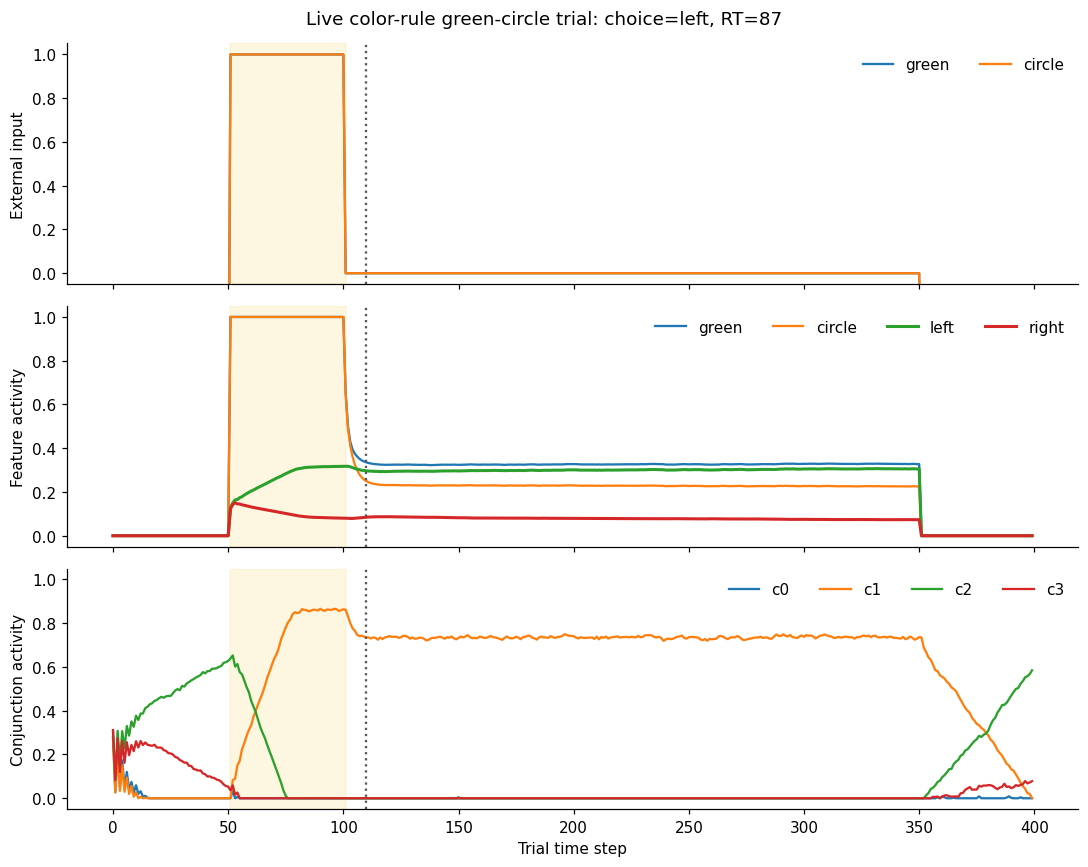

In [40]:
# Rebuild the exact external input used for this recorded trial.
choice_label = (
    "no response"
    if trial.chosen_response is None
    else trial.chosen_response.name.lower()
)
trial_input = _trial_epoch(trial.stimulus, small_config.protocol)
trial_time = np.arange(small_config.protocol.number_of_steps)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(trial_time, trial_input[:, Feature.GREEN], label="green")
axes[0].plot(trial_time, trial_input[:, Feature.CIRCLE], label="circle")
axes[0].set_ylabel("External input")

for feature in (Feature.GREEN, Feature.CIRCLE, Feature.LEFT, Feature.RIGHT):
    axes[1].plot(
        trial_time,
        trial.trajectory.feature_activity[:, feature],
        label=feature.name.lower(),
        linewidth=2 if feature in RESPONSE_FEATURES else 1.5,
    )
axes[1].set_ylabel("Feature activity")

for unit_index in range(number_of_conjunction_units_for_figure):
    axes[2].plot(
        trial_time,
        trial.trajectory.conjunction_activity[:, unit_index],
        label=f"c{unit_index}",
    )
axes[2].set_ylabel("Conjunction activity")
axes[2].set_xlabel("Trial time step")

for ax in axes:
    ax.axvspan(51, 101, color="#f4d35e", alpha=0.18)
    ax.axvline(110, color="0.35", linestyle=":")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc="upper right", ncol=4, frameon=False)

fig.suptitle(
    f"Live color-rule green-circle trial: choice={choice_label}, "
    f"RT={trial.reaction_time_in_steps:.0f}"
)
fig.tight_layout()
plt.show()

### Why left wins in this trial

Green and circle are both present. The color-block instructions have strengthened the recurrent route linking green with the left response. Circle still supports the competing right response, which is why this incongruent stimulus can be slower.

The activity plot above is the evidence for this particular run: it shows the actual input, feature activity, conjunction activity, selected response, and reaction time.

# Part VII: Does the cleaned baseline behave as expected?

## [Example] Run the seed-0 baseline across 20 blocks

`summarize_behavior(trials)` returns a `BehavioralSummary` containing overall accuracy and reaction times for correct congruent and incongruent trials. The congruency effect is:

**incongruent RT − congruent RT**

A positive value means conflicting stimulus dimensions slowed the model.

In [41]:
# the baseline alternates 20 blocks, giving 240 trials in total
baseline_result = run_blocked_experiment(
    BlockedExperimentConfig(seed=0, number_of_blocks=20)
)
# turn all individual trials into the main behavioural measurements
behavior = summarize_behavior(baseline_result.trials)

print('number of trials:', len(baseline_result.trials))
for name, value in behavior.as_dictionary().items():
    print(f'{name:38s} {value:.3f}')

# check the scientific behavior while allowing implementation cleanup
assert len(baseline_result.trials) == 240
assert behavior.accuracy > 0.90
assert behavior.congruency_effect_in_steps > 0.0
assert baseline_result.amplifying_eigenvalue_count_by_block[-1] >= 1
print("SELF-CHECK PASSED: high accuracy and a positive congruency effect remain.")


number of trials: 240
accuracy                               0.992
mean_reaction_time_in_steps            37.189
congruent_reaction_time_in_steps       29.308
incongruent_reaction_time_in_steps     45.203
congruency_effect_in_steps             15.895
SELF-CHECK PASSED: high accuracy and a positive congruency effect remain.


## [Example] Recompute the 20-seed behavioral benchmark

The paper reports averages across 20 random seeds. The next cell uses the same number of seeds, numbered 0 through 19, and prints the two sets of values side by side. The paper does not identify its exact seed values.

This benchmark is substantially lighter than the optional TMS grid, although it can still take roughly a minute depending on the Colab runtime. Its purpose is to make the quantitative comparison reproducible inside this single notebook.

In [42]:
# Recompute the cleaned aggregate instead of relying on a copied result table.
paper_behavioral_benchmark = {
    "accuracy": 0.964,
    "congruent RT": 30.14,
    "incongruent RT": 50.19,
    "congruency cost": 20.05,
}

benchmark_start_time = time.perf_counter()
cleaned_seed_summaries = []

for seed in range(20):
    seed_result = run_blocked_experiment(
        BlockedExperimentConfig(seed=seed, number_of_blocks=20)
    )
    cleaned_seed_summaries.append(
        summarize_behavior(seed_result.trials)
    )

cleaned_behavioral_benchmark = {
    "accuracy": float(np.mean([s.accuracy for s in cleaned_seed_summaries])),
    "congruent RT": float(
        np.mean([s.congruent_reaction_time_in_steps for s in cleaned_seed_summaries])
    ),
    "incongruent RT": float(
        np.mean([s.incongruent_reaction_time_in_steps for s in cleaned_seed_summaries])
    ),
    "congruency cost": float(
        np.mean([s.congruency_effect_in_steps for s in cleaned_seed_summaries])
    ),
}

print(
    f"20-seed baseline finished in "
    f"{time.perf_counter() - benchmark_start_time:.1f} seconds."
)
print(f"{'measure':18s} {'paper':>12s} {'cleaned':>12s} {'difference':>12s}")

for measure in paper_behavioral_benchmark:
    paper_value = paper_behavioral_benchmark[measure]
    cleaned_value = cleaned_behavioral_benchmark[measure]
    if measure == "accuracy":
        print(
            f"{measure:18s} {100 * paper_value:11.1f}% "
            f"{100 * cleaned_value:11.1f}% "
            f"{100 * (cleaned_value - paper_value):+11.1f} pp"
        )
    else:
        print(
            f"{measure:18s} {paper_value:12.2f} "
            f"{cleaned_value:12.2f} "
            f"{cleaned_value - paper_value:+12.2f}"
        )

print(
    "Both implementations show high accuracy and a positive incongruency cost. "
    "This checks scale and direction; it is not a formal equivalence test."
)

20-seed baseline finished in 46.4 seconds.
measure                   paper      cleaned   difference
accuracy                  96.4%        95.3%        -1.1 pp
congruent RT              30.14        29.19        -0.95
incongruent RT            50.19        50.98        +0.79
congruency cost           20.05        21.79        +1.74
Both implementations show high accuracy and a positive incongruency cost. This checks scale and direction; it is not a formal equivalence test.


## [Example] Plot behavior from the live seed-0 baseline

> **Live figure:** the bars below are calculated from `baseline_result`, the seed-0, 20-block experiment run above.

The figure answers two direct questions: does the model respond accurately, and are incongruent trials slower than congruent trials? The 20-seed cell above provides the aggregate comparison with the paper; this plot keeps one seed visible so its source is easy to inspect.

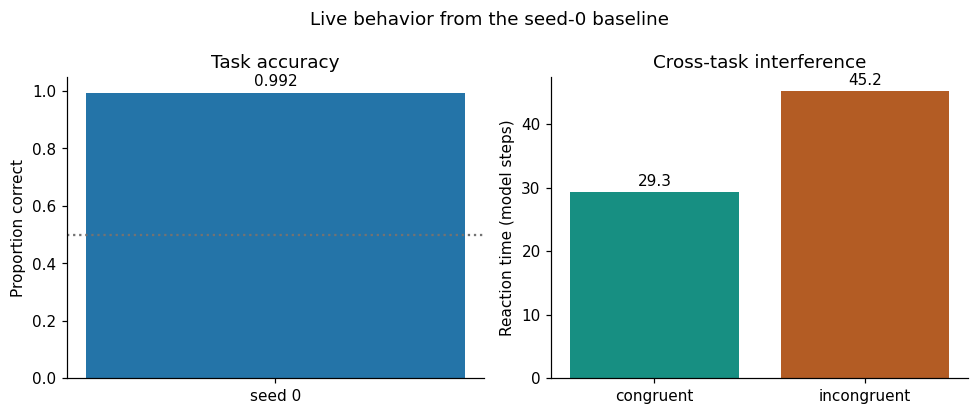

In [43]:
# Plot only measurements calculated from the current baseline_result.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

axes[0].bar(["seed 0"], [behavior.accuracy], color="#2474a8")
axes[0].axhline(0.5, color="0.45", linestyle=":", label="chance")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Proportion correct")
axes[0].set_title("Task accuracy")
axes[0].text(0, behavior.accuracy + 0.025, f"{behavior.accuracy:.3f}", ha="center")

rt_values = [
    behavior.congruent_reaction_time_in_steps,
    behavior.incongruent_reaction_time_in_steps,
]
axes[1].bar(["congruent", "incongruent"], rt_values, color=["#178f82", "#b35c24"])
axes[1].set_ylabel("Reaction time (model steps)")
axes[1].set_title("Cross-task interference")
for index, value in enumerate(rt_values):
    axes[1].text(index, value + 1, f"{value:.1f}", ha="center")

fig.suptitle("Live behavior from the seed-0 baseline")
fig.tight_layout()
plt.show()

## [Example] Measure relevant and irrelevant feature separation

Before fitting a decoder, we can inspect a simple quantity directly:

**separation = absolute activity difference between the two alternatives in a feature pair**

For a color trial, green-versus-blue is relevant and square-versus-circle is irrelevant. The assignment reverses for a shape trial.

> **Live figure:** every point is averaged from correct trials in `baseline_result`. This direct activity measure prepares the intuition for the cross-validated decoder that follows.

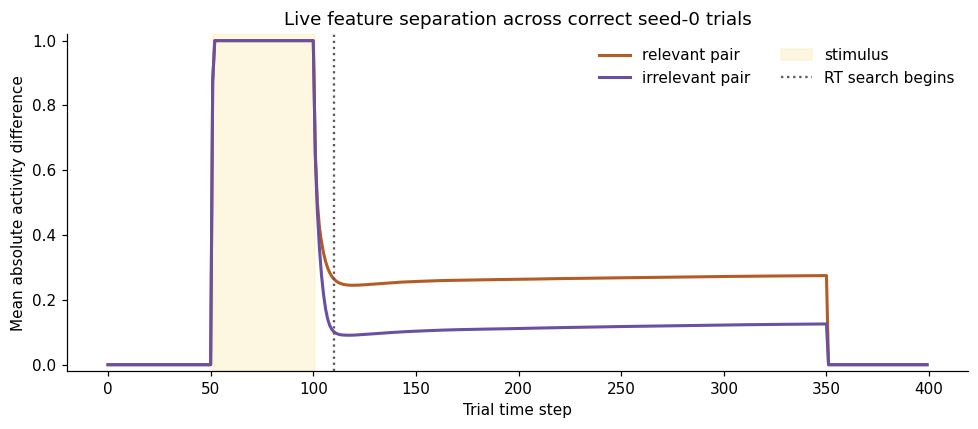

In [44]:
# Calculate relevant and irrelevant within-pair separation on every correct trial.
relevant_separation = []
irrelevant_separation = []

for recorded_trial in baseline_result.trials:
    if not recorded_trial.correct:
        continue

    activity = recorded_trial.trajectory.feature_activity
    color_difference = np.abs(
        activity[:, Feature.GREEN] - activity[:, Feature.BLUE]
    )
    shape_difference = np.abs(
        activity[:, Feature.SQUARE] - activity[:, Feature.CIRCLE]
    )

    if recorded_trial.task == Task.COLOR:
        relevant_separation.append(color_difference)
        irrelevant_separation.append(shape_difference)
    else:
        relevant_separation.append(shape_difference)
        irrelevant_separation.append(color_difference)

mean_relevant_separation = np.mean(relevant_separation, axis=0)
mean_irrelevant_separation = np.mean(irrelevant_separation, axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mean_relevant_separation, label="relevant pair", color="#b35c24", linewidth=2)
ax.plot(mean_irrelevant_separation, label="irrelevant pair", color="#6950a1", linewidth=2)
ax.axvspan(51, 101, color="#f4d35e", alpha=0.18, label="stimulus")
ax.axvline(110, color="0.35", linestyle=":", label="RT search begins")
ax.set(
    xlabel="Trial time step",
    ylabel="Mean absolute activity difference",
    title="Live feature separation across correct seed-0 trials",
    ylim=(-0.02, 1.02),
)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

## A cleaned version of the paper's decoder

A decoder receives the pattern across a population at one time step. It learns to distinguish green from blue or square from circle.

The paper and public analysis use logistic regression with the L-BFGS solver. This notebook keeps that solver, decodes the four sensory feature units rather than the two motor units, and applies a clearer validation scheme: complete blocks are held out and performance is measured with balanced accuracy.

An accuracy of 0.5 is chance for a two-way choice. Higher accuracy means that the population activity contains readable information about that feature.

We calculate two curves:

- **relevant information:** color during color blocks and shape during shape blocks;
- **irrelevant information:** shape during color blocks and color during shape blocks.

A decoder is an analysis tool. The attractor network does not contain this logistic-regression classifier when it chooses left or right.

### Helper 1: translate a trial into a label and an activity pattern

`_stimulus_label(...)` converts green/blue or square/circle into the binary labels 0 and 1. `_population_activity(...)` selects either the four sensory feature units or the four conjunction units. The left and right motor units are excluded from feature decoding, matching the public behavioral-analysis pipeline.

In [45]:
# translate an experimental feature into the two labels used by the decoder
def _stimulus_label(trial: TrialResult, dimension: Task) -> int:
    """Return 0 or 1 for the requested stimulus dimension."""

    # for color, green becomes 0 and blue becomes 1
    if dimension == Task.COLOR:
        return int(trial.stimulus.color == Feature.BLUE)

    # for shape, square becomes 0 and circle becomes 1
    return int(trial.stimulus.shape == Feature.CIRCLE)


# select the population pattern that will be given to logistic regression
def _population_activity(trial: TrialResult, population: str) -> np.ndarray:
    """Select the time-by-unit array for one population."""

    if population == "feature":
        # use green, blue, square and circle; exclude left and right
        return trial.trajectory.feature_activity[:, list(SENSORY_FEATURES)]
    if population == "conjunction":
        # all four flexible conjunction units enter this decoder
        return trial.trajectory.conjunction_activity

    # reject a misspelled population instead of silently selecting the wrong data
    raise ValueError("population must be 'feature' or 'conjunction'")


### Helper 2: train and test across held-out blocks

`decode_dimension_over_time(...)` repeats the same procedure at every requested time step:

1. reserve complete blocks for testing;
2. fit L-BFGS logistic regression on the remaining blocks;
3. predict the feature labels in the unseen blocks;
4. average balanced accuracy across folds.

As in the paper, only correct trials enter the decoder. Complete blocks are held out so activity from the same block cannot appear in both training and test data. Balanced accuracy gives both feature alternatives equal importance. Five folds match the paper's main decoding design, while the explicit block split makes the validation boundary easier to audit. If severe task failure leaves too few correct examples, the decoder returns `NaN` because that comparison is undefined.

In [46]:
def decode_dimension_over_time(
    trials,
    *,
    task: Task,
    decoded_dimension: Task,
    population: str,
    time_steps: np.ndarray,
    number_of_folds: int = 5,
) -> np.ndarray:
    """Decode one stimulus dimension within one task context."""

    # validate the requested timeline before starting the expensive decoder fits
    time_step_values = np.asarray(time_steps)
    if time_step_values.ndim != 1 or time_step_values.size == 0:
        raise ValueError("time_steps must be a non-empty one-dimensional array")
    if not np.issubdtype(time_step_values.dtype, np.integer):
        raise ValueError("time_steps must contain integers")
    time_step_values = time_step_values.astype(int, copy=False)
    if not isinstance(number_of_folds, (int, np.integer)) or number_of_folds < 2:
        raise ValueError("number_of_folds must be an integer of at least 2")

    # match the paper by decoding only correct trials from the requested task
    selected_trials = [
        trial for trial in trials
        if trial.correct and trial.task == task
    ]
    if not selected_trials:
        return np.full(time_step_values.size, np.nan)

    # these arrays stay aligned: one label, block and activity movie per trial
    labels = np.array(
        [_stimulus_label(trial, decoded_dimension) for trial in selected_trials]
    )
    groups = np.array([trial.block_index for trial in selected_trials])
    activity = np.stack(
        [_population_activity(trial, population) for trial in selected_trials]
    )

    # activity has shape trial x time x unit, so axis 1 limits valid time points
    if np.any(time_step_values < 0) or np.any(time_step_values >= activity.shape[1]):
        raise ValueError(
            f"time_steps must lie between 0 and {activity.shape[1] - 1}"
        )

    # decoding is undefined without enough blocks or both feature alternatives
    available_blocks = np.unique(groups)
    if number_of_folds > len(available_blocks):
        return np.full(time_step_values.size, np.nan)
    if np.unique(labels).size != 2:
        return np.full(time_step_values.size, np.nan)

    # build block-held-out folds once, then reuse them at every time step
    splitter = GroupKFold(n_splits=number_of_folds)
    folds = list(splitter.split(activity, labels, groups))
    accuracy = np.empty(time_step_values.size, dtype=float)

    # fit a separate decoder to each moment in the trial
    for time_index, time_step in enumerate(time_step_values):
        fold_scores = []
        for train_indices, test_indices in folds:
            train_labels = labels[train_indices]
            test_labels = labels[test_indices]

            # a fold needs both alternatives in training and testing
            if np.unique(train_labels).size < 2 or np.unique(test_labels).size < 2:
                continue

            # class weighting and balanced accuracy give both labels equal importance
            decoder = LogisticRegression(
                solver="lbfgs",
                class_weight="balanced",
                max_iter=1000,
            )
            decoder.fit(activity[train_indices, time_step], train_labels)
            predictions = decoder.predict(activity[test_indices, time_step])
            fold_scores.append(
                balanced_accuracy_score(test_labels, predictions)
            )

        # average the held-out folds; keep undefined moments visible as NaN
        accuracy[time_index] = (
            float(np.mean(fold_scores)) if fold_scores else float("nan")
        )

    return accuracy


### Helper 3: combine color and shape blocks

`decode_by_relevance(...)` runs the decoder within both task contexts. It then averages color-in-color-blocks with shape-in-shape-blocks to obtain the relevant curve. The reverse pairing gives the irrelevant curve.

In [47]:
def decode_by_relevance(
    trials,
    *,
    population: str,
    time_steps: np.ndarray,
    number_of_folds: int = 5,
) -> tuple[np.ndarray, np.ndarray]:
    """Return task-relevant and task-irrelevant decoding curves."""

    # store one relevant and one irrelevant curve for each task context
    relevant_curves = []
    irrelevant_curves = []

    for task in Task:
        # color and shape are always each other's irrelevant dimension
        irrelevant_dimension = (
            Task.SHAPE if task == Task.COLOR else Task.COLOR
        )

        # decode the dimension currently required for the response
        relevant_curves.append(
            decode_dimension_over_time(
                trials,
                task=task,
                decoded_dimension=task,
                population=population,
                time_steps=time_steps,
                number_of_folds=number_of_folds,
            )
        )

        # decode the other stimulus dimension from the same trials
        irrelevant_curves.append(
            decode_dimension_over_time(
                trials,
                task=task,
                decoded_dimension=irrelevant_dimension,
                population=population,
                time_steps=time_steps,
                number_of_folds=number_of_folds,
            )
        )

    # average color and shape contexts into the two curves shown in the figure
    return (
        np.nanmean(relevant_curves, axis=0),
        np.nanmean(irrelevant_curves, axis=0),
    )


## [Example] Decode the live seed-0 baseline

To keep the teaching run quick, we decode every fifth model step. The five folds hold out complete blocks.

The two panels ask the same question of different populations. The feature panel uses only the four sensory units. The solid curve shows task-relevant information and the dashed curve shows task-irrelevant information.

> **Live figure:** every value is fitted and tested from `baseline_result` by the code below. The shaded region is the stimulus window and the dotted vertical line marks the start of response measurement.

feature     post-stimulus relevant=0.922, irrelevant=0.615
conjunction post-stimulus relevant=0.988, irrelevant=0.503


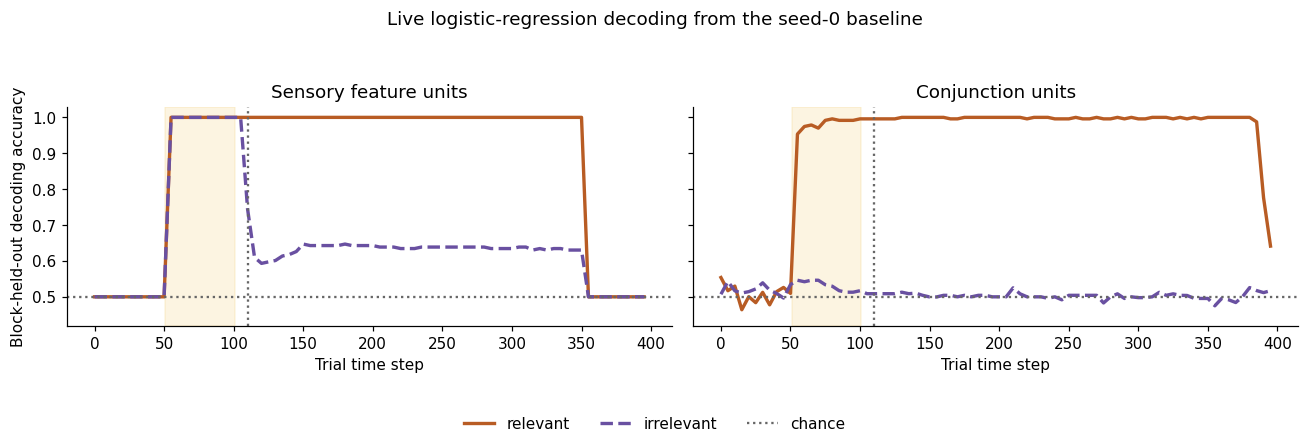

In [48]:
# decode every fifth step to keep the teaching example reasonably fast
DECODING_TIME_STEPS = np.arange(
    0,
    baseline_result.config.protocol.number_of_steps,
    5,
)

# run the same relevant-versus-irrelevant analysis for both populations
baseline_decoding = {}
for population in ("feature", "conjunction"):
    baseline_decoding[population] = decode_by_relevance(
        baseline_result.trials,
        population=population,
        time_steps=DECODING_TIME_STEPS,
        number_of_folds=5,
    )

# place sensory-feature and conjunction decoding on comparable axes
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
protocol = baseline_result.config.protocol

for axis, population in zip(axes, ("feature", "conjunction")):
    relevant_curve, irrelevant_curve = baseline_decoding[population]

    # solid and dashed lines distinguish relevant and irrelevant information
    axis.plot(
        DECODING_TIME_STEPS,
        relevant_curve,
        color="#b85c24",
        linewidth=2.2,
        label="relevant",
    )
    axis.plot(
        DECODING_TIME_STEPS,
        irrelevant_curve,
        color="#6950a1",
        linewidth=2.2,
        linestyle="--",
        label="irrelevant",
    )

    # 0.5 is chance; the shaded interval shows when the stimulus is present
    axis.axhline(0.5, color="0.4", linestyle=":", label="chance")
    axis.axvspan(
        protocol.stimulus_window.start,
        protocol.stimulus_window.stop,
        color="#f0c75e",
        alpha=0.18,
    )
    axis.axvline(protocol.response_search_start, color="0.4", linestyle=":")
    axis.set(
        xlabel="Trial time step",
        title=(
            "Sensory feature units"
            if population == "feature"
            else "Conjunction units"
        ),
        ylim=(0.42, 1.03),
    )

# one shared legend avoids covering either population's curves
axes[0].set_ylabel("Block-held-out decoding accuracy")
fig.suptitle("Live logistic-regression decoding from the seed-0 baseline")
fig.legend(
    axes[0].get_lines()[:3],
    ("relevant", "irrelevant", "chance"),
    frameon=False,
    loc="lower center",
    ncol=3,
)
fig.tight_layout(rect=(0, 0.12, 1, 0.93))
plt.show()

# summarize the period after response measurement begins with one number
for population, (relevant_curve, irrelevant_curve) in baseline_decoding.items():
    after_stimulus = DECODING_TIME_STEPS >= protocol.response_search_start
    print(
        f"{population:11s} post-stimulus relevant={np.nanmean(relevant_curve[after_stimulus]):.3f}, "
        f"irrelevant={np.nanmean(irrelevant_curve[after_stimulus]):.3f}"
    )


# Part VIII: Where do eigenvalues enter?

## A reduced measure of learned recurrent amplification

W is rectangular (6 x 4), so the paper analyzes the square matrix **W W.T** (6 x 6). Its eigenvectors describe directions in feature space.

Its eigenvalues describe how strongly the learned feature -> conjunction -> feature loop can amplify those directions in a simplified linear view.

The paper counts eigenvalues greater than 1. In this diagnostic, values above 1 are called amplifying modes. `PlasticAttractor.feedback_eigenvalues()` returns the complete spectrum, while `number_of_amplifying_eigenvalues()` performs the threshold count.

Two additional summaries become useful in later extensions:

- the **largest eigenvalue**, which records the strongest simplified amplification;
- the **spectral gap**, which is the difference between the two largest eigenvalues.

The paper's main diagnostic is the count above 1. We calculate the other two here so their definitions appear only after eigenvalues have been introduced.

> **Caveat:** an eigenvalue of W W.T provides an amplification proxy. Geometric basin depth requires a different analysis because the full network also contains gains, self-excitation, inhibition, noise, clipping, and plasticity.

## [Example] Calculate the live feedback spectrum

In [49]:
# use the learned matrix after all 20 blocks
final_W = baseline_result.final_weights

# W W.T describes amplification in the six-dimensional feature population
eigenvalues = np.linalg.eigvalsh(final_W @ final_W.T)
largest_eigenvalue = float(eigenvalues[-1])
spectral_gap = float(eigenvalues[-1] - eigenvalues[-2])

print('W shape:', final_W.shape)
print('W W.T shape:', (final_W @ final_W.T).shape)
print('final eigenvalues:', np.round(eigenvalues, 3))
print('values above 1:', int(np.sum(eigenvalues > 1.0)))
print('largest eigenvalue:', round(largest_eigenvalue, 3))
print('spectral gap:', round(spectral_gap, 3))
print('count after each block:', baseline_result.amplifying_eigenvalue_count_by_block)

W shape: (6, 4)
W W.T shape: (6, 6)
final eigenvalues: [-0.     0.     0.     0.029  3.85   4.794]
values above 1: 2
largest eigenvalue: 4.794
spectral gap: 0.944
count after each block: (2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)


## [Example] Plot the live eigenvalue diagnostic

> **Live figure:** both panels use the matrix and block counts stored in `baseline_result`.

The left panel shows the six eigenvalues of final W W.T. The right panel shows how many eigenvalues are above 1 after each block.

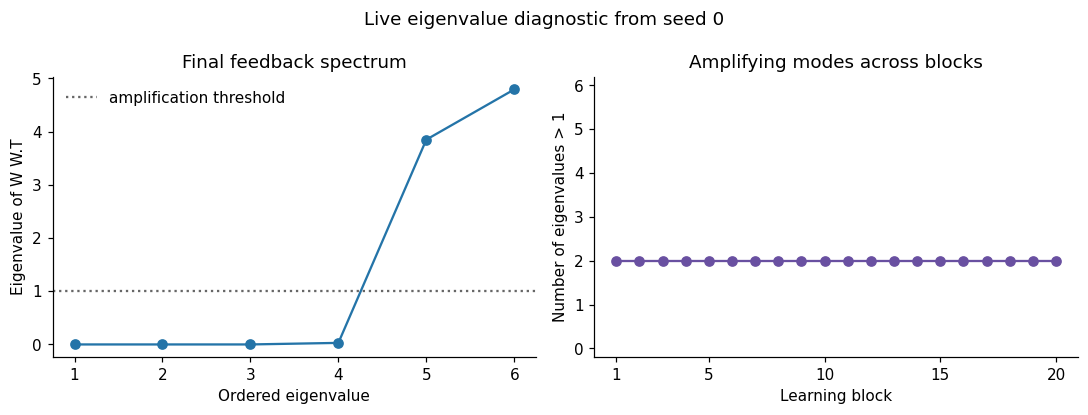

In [50]:
# Plot the spectrum and block-wise count from the current baseline run.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

ordered_indices = np.arange(1, len(eigenvalues) + 1)
axes[0].plot(ordered_indices, eigenvalues, marker="o", color="#2474a8")
axes[0].axhline(1.0, color="0.4", linestyle=":", label="amplification threshold")
axes[0].set(
    xlabel="Ordered eigenvalue",
    ylabel="Eigenvalue of W W.T",
    title="Final feedback spectrum",
    xticks=ordered_indices,
)
axes[0].legend(frameon=False)

block_numbers = np.arange(1, len(baseline_result.amplifying_eigenvalue_count_by_block) + 1)
axes[1].plot(
    block_numbers,
    baseline_result.amplifying_eigenvalue_count_by_block,
    marker="o",
    color="#6950a1",
)
axes[1].set(
    xlabel="Learning block",
    ylabel="Number of eigenvalues > 1",
    title="Amplifying modes across blocks",
    xticks=[1, 5, 10, 15, 20],
    yticks=range(0, 7),
    ylim=(-0.2, 6.2),
)

fig.suptitle("Live eigenvalue diagnostic from seed 0")
fig.tight_layout()
plt.show()

# Part IX: Perturbation and the paper-described frozen-weight control

The paper perturbs the conjunction population with a TMS-like maximum-activity clamp. It also describes a control in which learning is frozen after the two rule instructions, allowing the authors to test whether ongoing Hebbian updates help create the perturbation effect.

The supplementary repository file contains both update choices, with the frozen alternative presented as commented code that must be enabled manually. This notebook makes the two conditions explicit parameters and compares them directly.

This section first runs a short teaching comparison. A guarded option at the end can run the full cleaned condition grid. These analyses explain the published model and remain separate from our later task-switching proposal.

## [Example] Inspect one perturbation window

Translate one public-code label into its actual model-step duration, then run a
short two-block demonstration.

In [51]:
# reproduce the public code's pulse labelled 11
pulse = author_tms_pulse(11)
print('public-code label:', 11)
print('half-open window:', pulse.window.start, pulse.window.stop)
print('actual duration:', pulse.duration_in_steps, 'steps')

# use only two blocks here because this cell demonstrates the mechanism
illustrative_tms_result = run_blocked_experiment(
    BlockedExperimentConfig(
        seed=0,
        number_of_blocks=2,
        perturbation=pulse,
    )
)
print(summarize_behavior(illustrative_tms_result.trials).as_dictionary())

public-code label: 11
half-open window: 89 101
actual duration: 12 steps
{'accuracy': 1.0, 'mean_reaction_time_in_steps': 164.625, 'congruent_reaction_time_in_steps': 165.58333333333334, 'incongruent_reaction_time_in_steps': 163.66666666666666, 'congruency_effect_in_steps': -1.9166666666666856}


## What does freezing the weights test?

Both versions receive the two rule instructions at the beginning of every block.

- **Ongoing learning:** Hebbian updates continue throughout every 400-step trial epoch, including the pre-stimulus, stimulus, response, and final inactive phases.
- **Frozen after instruction:** Hebbian updates stop for all steps of every trial epoch, so TMS activity cannot rewrite W after the two instructions.

The comparison asks whether TMS changes behavior and information coding through neural activity alone, or partly through synaptic changes that affect later steps of the same trial and subsequent trials.

### `TMSPlasticityComparison`: one organized result

This frozen data class stores arrays with the same order: plasticity condition x seed x TMS dose. Keeping the axes explicit prevents conditions from being mixed up later.

In [52]:
# keep every TMS result in condition x seed x dose order
@dataclass(frozen=True)
class TMSPlasticityComparison:
    """Behavioral and decoding summaries from a paired TMS comparison."""

    # these labels describe the three axes shared by every stored measurement
    condition_labels: tuple[str, ...]
    seeds: np.ndarray
    doses: np.ndarray

    # behavior is stored once for every condition, seed and dose
    accuracy: np.ndarray
    congruency_effect: np.ndarray

    # decoding is stored separately by population and task relevance
    feature_relevant_decoding: np.ndarray
    feature_irrelevant_decoding: np.ndarray
    conjunction_relevant_decoding: np.ndarray
    conjunction_irrelevant_decoding: np.ndarray


### Run the same TMS grid with and without trial plasticity

`run_tms_plasticity_comparison(...)` pairs the two conditions by using the same model seeds, doses, and block counts. For every run it records behavior and the mean decoding accuracy across the requested time steps.

The compact study samples decoding every twentieth step. The optional full study uses every step.

In [53]:
# the Boolean value controls whether Hebbian updates continue during trials
PLASTICITY_CONDITIONS = (
    ("ongoing learning", True),
    ("frozen after instruction", False),
)


def run_tms_plasticity_comparison(
    *,
    seeds,
    doses,
    number_of_blocks: int,
    decoding_time_steps: np.ndarray,
    show_progress: bool = False,
) -> TMSPlasticityComparison:
    """Compare TMS effects with trial plasticity active or frozen."""

    # turn the requested seeds, doses and time steps into arrays
    # this lets us check them once and reuse them throughout the study
    seed_values = np.asarray(tuple(seeds), dtype=int)
    dose_values = np.asarray(tuple(doses), dtype=int)
    time_step_values = np.asarray(decoding_time_steps, dtype=int)

    # reject incomplete or ambiguous grids before starting long simulations
    if seed_values.size == 0:
        raise ValueError("At least one seed is required")
    if number_of_blocks < 4 or number_of_blocks % 2:
        raise ValueError("number_of_blocks must be even and at least 4")
    if dose_values.size == 0 or dose_values[0] != 0:
        raise ValueError("doses must begin with the no-TMS value 0")
    if np.any(dose_values < 0) or np.any(np.diff(dose_values) <= 0):
        raise ValueError("doses must be unique, increasing, and non-negative")
    if time_step_values.size == 0:
        raise ValueError("At least one decoding time step is required")
    if np.any(time_step_values < 0) or np.any(time_step_values >= 400):
        raise ValueError("decoding time steps must lie between 0 and 399")

    # every metric uses the same condition x seed x dose array shape
    shape = (
        len(PLASTICITY_CONDITIONS),
        len(seed_values),
        len(dose_values),
    )
    stored_metrics = {
        name: np.empty(shape, dtype=float)
        for name in (
            "accuracy",
            "congruency_effect",
            "feature_relevant_decoding",
            "feature_irrelevant_decoding",
            "conjunction_relevant_decoding",
            "conjunction_irrelevant_decoding",
        )
    }

    # each task needs enough blocks to create independent held-out folds
    number_of_folds = min(5, number_of_blocks // 2)
    total_runs = int(np.prod(shape))
    completed_runs = 0

    # these three loops correspond directly to the three result-array axes
    for condition_index, (_, learn_during_trials) in enumerate(
        PLASTICITY_CONDITIONS
    ):
        for seed_index, seed in enumerate(seed_values):
            for dose_index, dose in enumerate(dose_values):
                # run one complete blocked experiment for this grid position
                result = run_blocked_experiment(
                    BlockedExperimentConfig(
                        seed=int(seed),
                        number_of_blocks=number_of_blocks,
                        perturbation=author_tms_pulse(int(dose)),
                        learn_during_trials=learn_during_trials,
                    )
                )

                # store accuracy and the incongruent-minus-congruent RT effect
                behavior = summarize_behavior(result.trials)
                metric_index = (condition_index, seed_index, dose_index)
                stored_metrics["accuracy"][metric_index] = behavior.accuracy
                stored_metrics["congruency_effect"][metric_index] = (
                    behavior.congruency_effect_in_steps
                )

                # repeat the same decoding analysis for both neural populations
                for population in ("feature", "conjunction"):
                    relevant, irrelevant = decode_by_relevance(
                        result.trials,
                        population=population,
                        time_steps=time_step_values,
                        number_of_folds=number_of_folds,
                    )

                    # reduce each time course to its mean across sampled steps
                    stored_metrics[
                        f"{population}_relevant_decoding"
                    ][metric_index] = np.nanmean(relevant)
                    stored_metrics[
                        f"{population}_irrelevant_decoding"
                    ][metric_index] = np.nanmean(irrelevant)

                # optionally report about twenty evenly spaced progress updates
                completed_runs += 1
                if show_progress and (
                    completed_runs == 1
                    or completed_runs == total_runs
                    or completed_runs % max(1, total_runs // 20) == 0
                ):
                    print(
                        f"completed {completed_runs}/{total_runs} runs "
                        f"({100 * completed_runs / total_runs:.0f}%)"
                    )

    # package all aligned arrays into one organized result object
    return TMSPlasticityComparison(
        condition_labels=tuple(label for label, _ in PLASTICITY_CONDITIONS),
        seeds=seed_values,
        doses=dose_values,
        **stored_metrics,
    )


### Plot behavior and decoding with consistent axes

The first helper plots accuracy and the congruency effect. The second plots changes in decoding proportion relative to dose 0, following the logic of Supplementary Figure S4. Color identifies the plasticity condition and line style identifies relevant or irrelevant information. Feature decoding refers to the four sensory units.

In [54]:
def plot_tms_behavior(
    comparison: TMSPlasticityComparison,
    *,
    title: str,
) -> None:
    """Plot behavioral means across the stored seeds."""

    # color identifies whether weights continued learning during the trials
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
    colors = ("#b85c24", "#2474a8")

    for condition_index, (label, color) in enumerate(
        zip(comparison.condition_labels, colors)
    ):
        # average across seeds while retaining one point for every TMS dose
        axes[0].plot(
            comparison.doses,
            np.nanmean(comparison.accuracy[condition_index], axis=0),
            marker="o",
            color=color,
            label=label,
        )
        axes[1].plot(
            comparison.doses,
            np.nanmean(comparison.congruency_effect[condition_index], axis=0),
            marker="o",
            color=color,
            label=label,
        )

    # chance accuracy and zero congruency effect provide visual reference points
    axes[0].axhline(0.5, color="0.4", linestyle=":")
    axes[0].set(
        xlabel="TMS dose label",
        ylabel="Accuracy",
        title="Task performance",
        ylim=(0.45, 1.03),
    )
    axes[1].axhline(0, color="0.4", linestyle=":")
    axes[1].set(
        xlabel="TMS dose label",
        ylabel="Incongruent RT - congruent RT",
        title="Congruency effect",
    )
    for axis in axes:
        axis.set_xticks(comparison.doses)
    axes[0].legend(frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_tms_decoding_change(
    comparison: TMSPlasticityComparison,
    *,
    title: str,
) -> None:
    """Plot decoding change relative to each condition's dose 0."""

    # both populations share a y-axis because they show the same measurement
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    colors = ("#b85c24", "#2474a8")

    for axis, population in zip(axes, ("conjunction", "feature")):
        # retrieve the relevant and irrelevant arrays for this population
        relevant_values = getattr(
            comparison,
            f"{population}_relevant_decoding",
        )
        irrelevant_values = getattr(
            comparison,
            f"{population}_irrelevant_decoding",
        )

        for condition_index, (label, color) in enumerate(
            zip(comparison.condition_labels, colors)
        ):
            # subtract each seed's dose-0 value before averaging across seeds
            relevant_change = (
                relevant_values[condition_index]
                - relevant_values[condition_index, :, [0]].T
            )
            irrelevant_change = (
                irrelevant_values[condition_index]
                - irrelevant_values[condition_index, :, [0]].T
            )

            # line style distinguishes task-relevant from irrelevant information
            axis.plot(
                comparison.doses,
                np.nanmean(relevant_change, axis=0),
                color=color,
                marker="o",
                label=f"{label}, relevant",
            )
            axis.plot(
                comparison.doses,
                np.nanmean(irrelevant_change, axis=0),
                color=color,
                marker="s",
                linestyle="--",
                label=f"{label}, irrelevant",
            )

        # zero means decoding is unchanged from the no-TMS condition
        axis.axhline(0, color="0.4", linestyle=":")
        axis.set(
            xlabel="TMS dose label",
            title=(
                "Sensory feature units"
                if population == "feature"
                else "Conjunction units"
            ),
        )
        axis.set_xticks(comparison.doses)

    axes[0].set_ylabel("Change in decoding accuracy from dose 0")
    axes[1].legend(frameon=False, fontsize=9)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


## [Example] Run the compact plastic-versus-frozen comparison

The teaching version uses:

- one seed;
- four blocks per dose;
- six selected dose labels;
- decoding every twentieth model step.

This is enough to inspect the mechanism and the analysis workflow. One seed cannot establish a reliable population-level effect.

> **Live analysis:** every value is simulated and decoded below. The complete design remains available in the guarded section that follows.

In [55]:
# choose a small grid that keeps the live teaching example practical
COMPACT_TMS_DOSES = np.array([0, 5, 10, 11, 14, 19])
COMPACT_DECODING_TIME_STEPS = np.arange(0, 400, 20)

# time the complete comparison so students know its computational cost
compact_start_time = time.perf_counter()
compact_tms_comparison = run_tms_plasticity_comparison(
    seeds=(0,),
    doses=COMPACT_TMS_DOSES,
    number_of_blocks=4,
    decoding_time_steps=COMPACT_DECODING_TIME_STEPS,
)
compact_runtime = time.perf_counter() - compact_start_time

# confirm both the runtime and the order of the first result-array axis
print(f"Compact comparison finished in {compact_runtime:.1f} seconds.")
print("Array order:", compact_tms_comparison.condition_labels)


Compact comparison finished in 8.9 seconds.
Array order: ('ongoing learning', 'frozen after instruction')


### [Example] Compare behavior

The accuracy panel shows when the model begins to fail. The congruency panel shows whether the reaction-time difference between incongruent and congruent trials changes with dose.

The two lines differ only in whether Hebbian updates continued throughout the complete 400-step trial epochs.

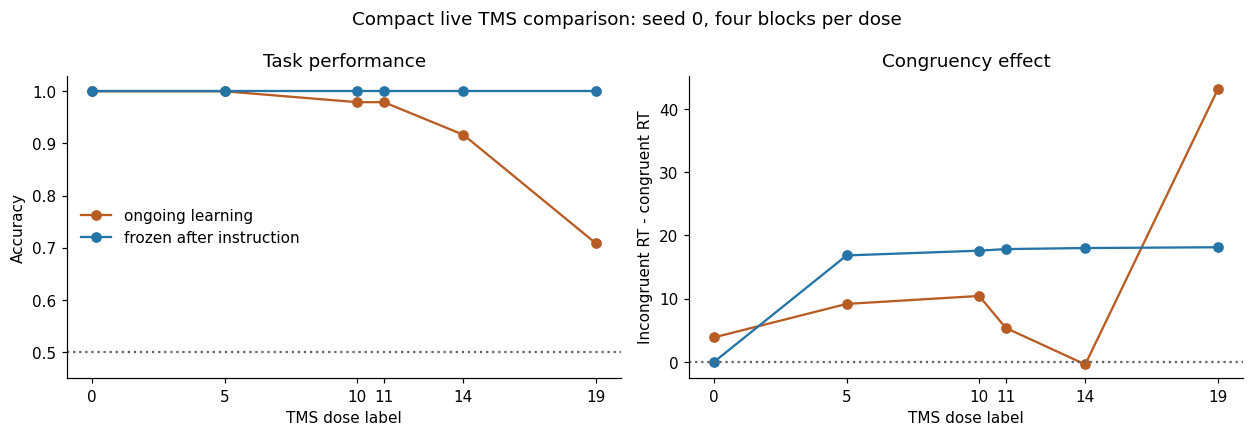

In [56]:
# average the stored seed results and plot both behavioral measurements
plot_tms_behavior(
    compact_tms_comparison,
    title="Compact live TMS comparison: seed 0, four blocks per dose",
)


### [Example] Compare information coding

Each curve is expressed relative to dose 0 within the same plasticity condition. A negative value means that the proportion decoded correctly became lower after TMS. The feature panel uses the four sensory units.

This compact figure samples the trial every twenty steps. It demonstrates the paper's ablation logic and should not be reported as the full multi-seed result.

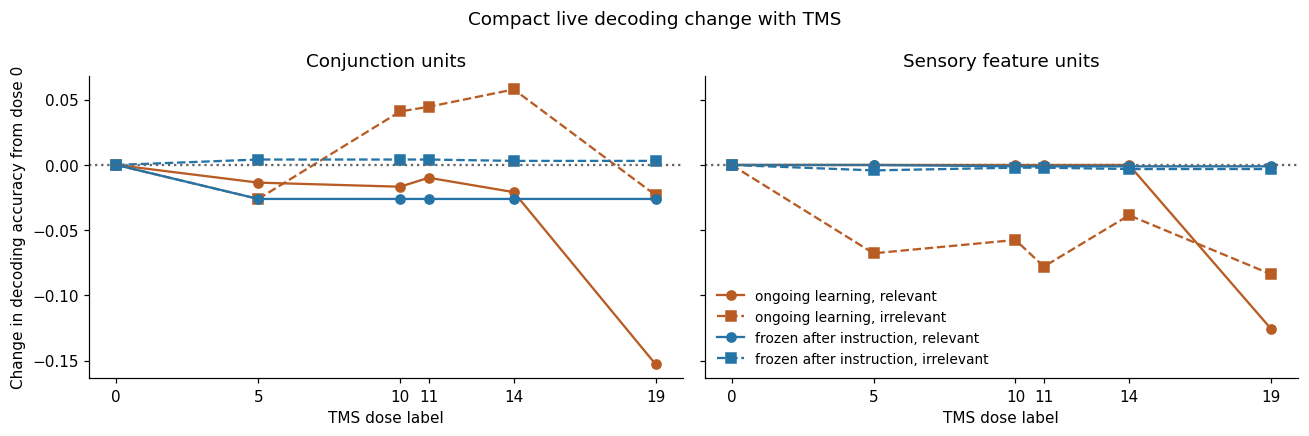

In [57]:
# show decoding change relative to dose 0 for both neural populations
plot_tms_decoding_change(
    compact_tms_comparison,
    title="Compact live decoding change with TMS",
)


## Optional full cleaned TMS grid

The next cell contains the 20-seed, 20-block, 20-dose version of this notebook's paired comparison. Decoding is calculated at all 400 steps and then averaged over the epoch, matching the summary logic of Supplementary Figure S4. It uses the cleaned all-trial TMS schedule defined above. The public supplementary code used a different half-trial schedule, recorded in Appendix A.

> **Runtime warning:** keep `RUN_FULL_CLEANED_TMS_GRID = False` for an ordinary teaching run. Setting it to `True` launches 800 full simulations and millions of logistic-regression fits. In Colab this can take hours, depending on the assigned runtime, and a disconnected session may lose unfinished results.

The option is visible and disabled by default. The compact analysis above is sufficient for understanding the method. The full grid expands the cleaned notebook design; it does not claim to reproduce every supplementary indexing choice line by line.

In [58]:
# keep the multi-hour analysis disabled during an ordinary teaching run
RUN_FULL_CLEANED_TMS_GRID = False

if RUN_FULL_CLEANED_TMS_GRID:
    # 2 plasticity conditions x 20 seeds x 20 doses gives 800 simulations
    print("RUNTIME WARNING: the full cleaned TMS grid has started.")
    print("It runs 800 simulations plus decoding at every step and may take hours.")
    full_start_time = time.perf_counter()

    # unlike the compact example, decode every one of the 400 model steps
    full_tms_comparison = run_tms_plasticity_comparison(
        seeds=range(20),
        doses=range(20),
        number_of_blocks=20,
        decoding_time_steps=np.arange(400),
        show_progress=True,
    )
    print(
        f"Full cleaned TMS grid finished in "
        f"{(time.perf_counter() - full_start_time) / 60:.1f} minutes."
    )
else:
    # use None to tell the plotting cell that no result exists
    full_tms_comparison = None
    print(
        "Full cleaned TMS grid skipped. "
        "Set RUN_FULL_CLEANED_TMS_GRID = True to run it."
    )


Full cleaned TMS grid skipped. Set RUN_FULL_CLEANED_TMS_GRID = True to run it.


### [Example] Plot the full cleaned-grid result when available

This cell remains fast when the full option is disabled. If the long run was requested, it generates the same two figures from the 20-seed averages.

In [59]:
# generate figures only when the optional long computation actually ran
if full_tms_comparison is None:
    print("No full cleaned-grid figures were generated in the default run.")
else:
    # reuse the compact-study plotting functions so both analyses are comparable
    plot_tms_behavior(
        full_tms_comparison,
        title="Full cleaned 20-seed plastic-versus-frozen TMS comparison",
    )
    plot_tms_decoding_change(
        full_tms_comparison,
        title="Full 20-seed decoding change with TMS",
    )


No full cleaned-grid figures were generated in the default run.


# Part X: Reference guide to the main code objects

This repository contains one self-contained teaching notebook, plus the minimal files needed to describe and license it. Every class and function used by Colab is defined above, and the reference guide below helps readers find them.

## Classes: the nouns

A class gives a meaningful name and structure to related data and behavior. A *frozen data class* is mainly a protected record. `PlasticAttractor` is different: it is a stateful simulator whose activity and weights change.

| Class | Represents | Important contents |
|---|---|---|
| `Feature` | a named position in the feature vector | green, blue, square, circle, left, right |
| `Task` | the relevant stimulus dimension | color or shape |
| `Stimulus` | one presented object | one color and one shape |
| `NetworkArchitecture` | population sizes and competing pairs | 6 features, 4 conjunctions |
| `ModelParameters` | numerical assumptions | gains, inhibition, noise, learning rates, bounds |
| `NetworkState` | activity after one update | feature and conjunction arrays |
| `WeightSnapshot` | read-only learning state at one moment | fast, slow, and combined W |
| `PlasticAttractor` | the live neural network | current activity, recurrent matrices, plastic W |
| `NetworkTrajectory` | one epoch's activity movie | time x feature and time x conjunction arrays |
| `TimeWindow` | an included-start/excluded-stop interval | start, stop, duration |
| `EpochProtocol` | experiment timing | windows, 400 steps, trial repeats |
| `ConjunctionClamp` | perturbation schedule | steps when conjunctions are forced to 1 |
| `BlockedExperimentConfig` | one reproducible simulation recipe | seed, blocks, timing, perturbation, trial learning |
| `TrialResult` | result of one stimulus trial | behavior plus complete trajectory |
| `ExperimentResult` | result of all blocks | all trials, block spectrum summary, final W |
| `BehavioralSummary` | compact behavioral report | accuracy and congruent/incongruent RT |
| `TMSPlasticityComparison` | paired perturbation analysis | condition x seed x dose arrays |

## Functions and methods: the verbs

| Function or method | Plain-language job |
|---|---|
| `Stimulus.relevant_feature(task)` | select color or shape from this object |
| `NetworkArchitecture.original()` | construct the paper's 6+4 architecture |
| `PlasticAttractor.reset_activity()` | clear current activity without erasing learned W |
| `PlasticAttractor.step(input, ...)` | perform one synchronous neural and Hebbian update |
| `PlasticAttractor.weight_snapshot()` | copy fast, slow, and combined W for inspection |
| `PlasticAttractor.feedback_eigenvalues()` | compute the complete spectrum of W W.T |
| `PlasticAttractor.number_of_amplifying_eigenvalues()` | count eigenvalues of W W.T above 1 |
| `_bounded_activity(values)` | clip rate values from 0 to 1 |
| `_update_plastic_weights()` | apply the fast and slow covariance updates |
| `run_epoch(model, inputs, protocol, ...)` | reset activity, run 400 steps, record the trajectory |
| `_instruction_vector(...)` | build one feature-response mapping example |
| `_instruction_vectors(task)` | create the task's two mapping examples |
| `_instruction_epoch(...)` | place one mapping vector into a 400-step schedule |
| `_stimulus_vector(stimulus)` | turn one color-shape object into six inputs |
| `_trial_epoch(...)` | place the stimulus vector into a 400-step schedule |
| `_correct_response(task, stimulus)` | compute the answer for scoring |
| `_measure_response(trajectory, protocol)` | choose left/right or no response and calculate RT |
| `_run_trial(...)` | run and package one complete stimulus trial |
| `author_tms_pulse(dose)` | translate the public label into a clamp window |
| `run_blocked_experiment(config)` | organize all instructions, trials, and blocks |
| `_mean_or_nan(values)` | summarize an available condition safely |
| `summarize_behavior(trials)` | reduce trial records to accuracy and RT summaries |
| `_stimulus_label(...)` | create the binary label used by a decoder |
| `_population_activity(...)` | select sensory-feature or conjunction activity |
| `decode_dimension_over_time(...)` | train and test one block-held-out decoder |
| `decode_by_relevance(...)` | combine color and shape decoding by task relevance |
| `run_tms_plasticity_comparison(...)` | pair ongoing and frozen-plasticity TMS runs |
| `plot_tms_behavior(...)` | plot accuracy and congruency across TMS doses |
| `plot_tms_decoding_change(...)` | plot decoding change relative to dose 0 |

The underscore is a reading hint. Public names form the normal workflow, while private helpers implement internal translations. A private helper can still be scientifically important. Normal callers can rely on the public workflow.

## Original repository -> notebook map

Use this as a lookup guide after reading the function list above.

```text
PlasticAttractorCode/
|
+-- plasticattractor_networksims.py
|   +-- task arrays and inputs       -> Parts I and V
|   +-- parameters and matrices      -> Part II
|   +-- neural update equations      -> Part III
|   +-- Hebbian weight update        -> Part IV
|   +-- block and trial loops        -> Part V
|   +-- response measurement         -> Part V
|
+-- plasticattractor_behaviouralanalysis.py
|   +-- accuracy, RT, congruency     -> Part VII
|   +-- correct-trial sensory arrays -> Part VII
|
+-- plasticattractor_decoding.py
|   +-- logistic decoding idea       -> Part VII
|       The notebook retains L-BFGS and adds block-held-out validation.
|
+-- plasticattracto_centralscript.py
    +-- baseline, eigenvalue, and main all-trial TMS analyses
        -> Parts VII to IX

SupplementaryMaterialCode/
|
+-- plasticattractor_networksims_TMSSHFL.py
|   +-- interleaved TMS schedule and manual plasticity toggle
|       -> Part IX and Appendix A
|
+-- plasticattracto_centralscript_TMSSHFL.py
    +-- 10-block, 20-seed supplementary dose grid
        -> Part IX and Appendix A
```

The main reorganization separates task meanings, neural equations, experiment scheduling, and analysis. The decoder and frozen-weight control also make their validation and plasticity choices explicit.

## Baseline and analysis call chains

```text
BlockedExperimentConfig
        |
run_blocked_experiment
        |
        +-- create PlasticAttractor
        |
        +-- for each alternating block
               +-- mapping examples -> run_epoch -> step x 400
               +-- stimulus trials  -> run_epoch -> _measure_response
        |
        +-- ExperimentResult
               +-- summarize_behavior
               +-- decode_by_relevance
               +-- eigenvalue summaries
```

The perturbation analysis repeatedly uses that baseline path:

```text
seeds x TMS doses x plasticity conditions
        |
run_tms_plasticity_comparison
        |
        +-- BlockedExperimentConfig
        +-- run_blocked_experiment
        +-- summarize_behavior
        +-- sensory-feature and conjunction decoding
        |
        +-- TMSPlasticityComparison -> plotting helpers
```

Reading tip: start at `run_blocked_experiment`, follow one instruction and one trial, then read `PlasticAttractor.step`. Return to the analysis branch after the baseline workflow is clear.

# Part XI: What the paper establishes and where its boundaries lie

## What the paper reports

Across its main and supplementary analyses, the paper reports:

1. high blocked-task accuracy and slower responses for incongruent stimuli;
2. stronger decoding of task-relevant information in conjunction and sensory-feature populations;
3. dose-dependent perturbation effects on behavior, decoding, and learned weights;
4. a relation between task failure and loss of amplifying eigenvalues;
5. a frozen-weight control suggesting that ongoing plasticity produces synaptic carry-over effects under perturbation;
6. a slow-weight ablation showing that the longer plasticity timescale supports the congruency effect and stable conjunction selectivity.

## What the executable notebook demonstrates directly

1. Rule instruction changes W through Hebbian covariance learning.
2. A later stimulus follows the learned recurrent loop toward a response.
3. The seed-0 baseline has high accuracy and a positive congruency cost.
4. The cleaned 20-seed behavioral benchmark has the same qualitative pattern and similar scale as the paper.
5. Relevant feature pairs remain more separated than irrelevant pairs after stimulus offset.
6. Block-held-out L-BFGS decoding reads task-relevant and task-irrelevant information from conjunction and sensory-feature populations.
7. The learned matrix contains two amplifying eigenvalues in the seed-0 run.
8. A compact live TMS analysis compares ongoing learning with weights frozen after instruction.

The full cleaned 20-seed perturbation grid is implemented behind `RUN_FULL_CLEANED_TMS_GRID`. It is disabled by default because its simulations and step-by-step decoder fits are intentionally slow. Appendix A records how this shared all-trial schedule differs from the public supplementary schedule.

## Important limits

- The task context is stable for 12 trials at a time and is installed through two mapping demonstrations.
- The model describes population rates; explicit spikes lie outside its scope.
- The perturbation uses a maximum-activity clamp. Biophysical TMS details are abstracted away.
- Reaction times use model steps defined by a global-peak rule. No calibration to human milliseconds is provided.
- Eigenvalues of W Wᵀ provide an amplification proxy; geometric basin depth remains unmeasured.
- Conjunction units are flexible mixed-selectivity populations whose columns start without human-readable labels.
- A successful computational reproduction demonstrates sufficiency under these assumptions. The brain may use different mechanisms.

# Final mental model

At the beginning of a block, the network experiences two relevant feature-response mappings. Hebbian learning changes fast and slow connections between six fixed feature units and four flexible conjunction units. The slow component also carries a weak bias across blocks.

Activity is set to zero before each new epoch, while the weights remain. A later stimulus activates both of its properties, and the same weights continue changing throughout the trial.

Recurrent feedback reactivates the conjunction pattern favored by the current rule, and response competition selects a motor unit.

Logistic-regression decoding asks how clearly color or shape can be read from conjunction activity or the four sensory-feature units. The frozen-weight control asks whether TMS changes later activity within a trial and subsequent trials partly by changing W.

The notebook generates its figures from the current run: activity, behavior, feature separation, decoding, eigenvalues, and the compact TMS control. The architecture schematic is the only qualitative figure and is labeled as such.

# Appendix A: Implementation notes from paper and public code to this notebook

This appendix is the scientific implementation record.

- **A1** records differences between the paper and public repository, followed by the notebook's explicit choice.
- **A2** records software and analysis cleanups that make the implementation safer or easier to inspect.
- **A3** records public-code behaviors intentionally retained for baseline comparability.

Future extensions should record consequential changes under the relevant subsection whenever they alter equations, timing, learning, response measurement, randomness, or analysis definitions.

## A1. How we resolved differences between the paper and repository

The paper and repository describe the same overall model. The points below record the implementation choices that matter for this notebook.

### 1. Source snapshot

The scientific reference is the bioRxiv version posted 11 September 2025. The executable reference is repository commit `3e125a2f78239ae5d3906d122ec9d62057a89b66` from 19 November 2025.

Recording both versions prevents later repository changes from silently altering what this notebook means by the public implementation.

### 2. Communication gains

The printed equations assign 0.04 to conjunction -> feature communication and 0.08 to feature -> conjunction communication. The public code uses 0.08 and 0.04 respectively.

The notebook uses the public-code values because they are connected to the executable results.

### 3. Direction of W

The paper's prose and matrix equations use different verbal directions for W.

The notebook defines direction from the dimensions: W has shape 6 x 4. Therefore `W @ conjunction_activity` produces six feature values, while `W.T @ feature_activity` produces four conjunction values. Transposing swaps dimensions and does not calculate an inverse.

### 4. Number of seeds

The paper reports 20 random seeds. The current public central script sets `n_seeds = 2`.

The default teaching figures use seed 0. A visible notebook cell recomputes the behavioral comparison across 20 seeds, numbered 0 through 19. The optional full TMS grid uses the same 20 notebook seeds when enabled.

### 5. Trial balance and response mappings

One figure caption describes four presentations of every stimulus in a 12-trial block. The Methods and code use three presentations of each of four stimuli. Another caption describes blue -> left, while the Methods and rule arrays use green -> left and blue -> right.

The notebook follows the Methods and executable arrays: three presentations per stimulus, green -> left, and blue -> right.

### 6. Timing

The paper describes rounded durations. Inclusive conditions in the 400-step public arrays produce slightly asymmetric boundaries, including a 251-step instruction window and inactive trial periods of 51 steps before the stimulus and 49 after the response.

The notebook preserves the realized array behavior and represents every interval explicitly with half-open `TimeWindow` objects.

### 7. TMS duration and eigenvalue sampling

A positive TMS label `d` includes both boundary steps in the public code, so it produces `d + 1` clamped updates. The paper also describes eigenvalue counts at the end of each block, while the public analysis averages several stored matrices from within a block.

The notebook reports both TMS label and actual duration, and records eigenvalues once after all 12 trials in a block.

### 8. Supplementary frozen-weight schedule

The public supplementary scripts use 10 blocks, apply TMS to a balanced half of the trials, and step through pulse labels from 0 to 38 in increments of 2. The network file contains both ongoing and frozen update blocks, with the frozen alternative commented out as a manual toggle. The main public TMS script applies TMS to every stimulus trial and uses labels from 0 to 19.

This notebook implements the paper-described freeze explicitly through `learn_during_trials`. For a direct paired comparison, it uses the cleaned all-trial schedule for both ongoing and frozen conditions. The analysis tests the same synaptic carry-over mechanism, while the schedule is not a line-by-line reproduction of the supplementary script.

## A2. What we cleaned up in the code

These changes make the model easier to inspect and extend. They preserve the main mechanism, while exact values from a particular random seed can differ from the public scripts.

### 1. Weight initialization

The public simulation creates several random W matrices during setup. One is unused, and another is replaced after the first network update. The slow component also begins between 0 and 1 before being clipped to its allowed maximum of 0.2.

The notebook directly initializes:

- fast weights between 0 and 1;
- slow weights between 0 and 0.2;
- combined W as fast W + slow W.

This removes discarded random matrices and starts both components inside their stated bounds.

### 2. Randomness and paired perturbations

The public scripts use NumPy's global random state. The cleaned model receives an explicit seeded `RandomState`.

The public clamp branch skips the conjunction-noise draw, so different clamp durations consume different random-number sequences. The notebook draws the noise and then applies the clamp. The clamped activity is unchanged, while paired doses retain aligned later noise and trial orders.

The removed initialization draws mean that the same seed does not produce an identical trajectory to the original scripts.

### 3. Scientific names

Numeric indices and nested dictionaries were replaced with names such as `Feature.GREEN`, `Task.COLOR`, `Stimulus`, and `TrialResult`.

This makes the code read like the experiment and allows invalid inputs to be rejected early.

### 4. Timing boundaries

Overlapping inclusive conditions were replaced with half-open windows such as `51:101`.

This preserves the actual steps selected by the public code while making durations easier to verify.

### 5. Safe saved results

Activity states are returned as independent copies. Weight snapshots contain copied, read-only arrays.

This prevents later activity or learning from silently changing a result that was saved earlier.

### 6. Separate levels of the simulation

The original nested simulation was divided into:

- `PlasticAttractor.step`: one neural and Hebbian update;
- `run_epoch`: one validated 400-step activity trajectory;
- `run_blocked_experiment`: instructions, trials, and blocks;
- `summarize_behavior`: accuracy and reaction-time analysis.

This lets us change an experimental schedule without rewriting the neural equations.

### 7. Decoder validation

The public decoder uses L-BFGS logistic regression, ordinary five-fold trial splitting, random undersampling, and the four sensory feature units. The notebook retains L-BFGS and the sensory-only population, while holding out complete blocks and using class weighting plus balanced accuracy. This makes the train-test boundary explicit and removes the extra imbalanced-learn dependency.

### 8. Missing responses

The public response code assumes that at least one motor unit crosses its retrospective threshold. The previous cleaned fallback silently returned left when no crossing existed.

The notebook now records no response, assigns `NaN` reaction time, and counts the trial as incorrect.

### 9. Early validation

Architecture groups, model parameters, timing windows, perturbation windows, epoch inputs, dose grids, and decoder time points are checked before a simulation begins.

This turns delayed indexing failures or silent defaults into short, local error messages.

### What these cleanups mean scientifically

We compare the cleaned model with the paper using a reproducible 20-seed behavioral benchmark, simulated activity trajectories, and explicitly defined analyses. Exact seed-level equality is not expected because initialization and random-number consumption were simplified.

## A3. Public-code behaviors preserved for baseline comparability

### Response selection

The public code finds 98% of the largest motor activity and uses `np.argwhere` on a response-by-time array. Row-major scanning places every left crossing before every right crossing. Left therefore wins whenever it crosses at any searched time, even if right crossed earlier.

The notebook preserves and explains this rule so its baseline remains comparable to the public implementation. It adds only an explicit no-response outcome for the otherwise undefined zero-activity case. A future task-switching experiment should compare this legacy rule with a symmetric measurement such as earliest threshold crossing across both responses.

### Ongoing learning during every time step

Weights update during instructions, stimulus presentation, response settlement, and inactive periods. This is part of the published mechanism and is preserved. Any future manipulation that freezes learning should state exactly which epochs and steps are frozen.

### Maximum-activity perturbation

The TMS-like manipulation forces all conjunction units to 1. It is a phenomenological perturbation rather than a biophysical TMS model. The notebook keeps it because it tests the paper's proposed circuit mechanism.